In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df = pd.read_csv('../dados/processed/pam_tratado.csv')
df.head()

,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,produto_codigo,produto_nome,valor,valor_is_inibido
0,N1,Brasil,1,Brasil,2003,2003,216,Área colhida,Hectares,40122,Milho (em grão),12965678.0,0
1,N1,Brasil,1,Brasil,2004,2004,216,Área colhida,Hectares,40122,Milho (em grão),12410677.0,0
2,N1,Brasil,1,Brasil,2005,2005,216,Área colhida,Hectares,40122,Milho (em grão),11549425.0,0
3,N1,Brasil,1,Brasil,2006,2006,216,Área colhida,Hectares,40122,Milho (em grão),12613094.0,0
4,N1,Brasil,1,Brasil,2007,2007,216,Área colhida,Hectares,40122,Milho (em grão),13767431.0,0


In [3]:
colunas_codigo = [c for c in df.columns if c.endswith('_codigo')]
df_nome = df.drop(columns=colunas_codigo)
df_nome.head()

,nivel_territorial_nome,territorio_nome,ano_nome,variavel_nome,unidade,produto_nome,valor,valor_is_inibido
0,Brasil,Brasil,2003,Área colhida,Hectares,Milho (em grão),12965678.0,0
1,Brasil,Brasil,2004,Área colhida,Hectares,Milho (em grão),12410677.0,0
2,Brasil,Brasil,2005,Área colhida,Hectares,Milho (em grão),11549425.0,0
3,Brasil,Brasil,2006,Área colhida,Hectares,Milho (em grão),12613094.0,0
4,Brasil,Brasil,2007,Área colhida,Hectares,Milho (em grão),13767431.0,0


In [4]:
df_nome.groupby('variavel_nome')['valor'].describe()

,count,mean,std,min,25%,50%,75%,max
variavel_nome,,,,,,,,
Quantidade produzida,28644.0,604053.393939,1.908910e+07,0.0,4.0,191.0,1050.00,782058236.0
Rendimento médio da produção,28644.0,6908.879486,1.308813e+04,0.0,87.0,420.0,8000.00,109078.0
Valor da produção,28644.0,87173.995147,2.164699e+06,0.0,4.0,117.0,852.00,137992403.0
Área colhida,28644.0,25737.543709,5.197323e+05,0.0,3.0,68.0,1230.00,22315010.0
Área plantada ou destinada à colheita,28644.0,26303.091922,5.308416e+05,0.0,3.0,70.0,1244.25,22546782.0


In [5]:
print("Valores nulos:", df_nome['valor'].isna().sum())
print("Valores inibidos (sigilo do IBGE):", df_nome['valor_is_inibido'].sum())
print("Linhas duplicadas:", df_nome.duplicated().sum())

Valores nulos: 0
Valores inibidos (sigilo do IBGE): 0
Linhas duplicadas: 0


In [6]:
territorios = df_nome['territorio_nome'].unique()
print(len(territorios))
print(territorios)

186
['Brasil' 'Ceará' 'Abaiara - CE' 'Acarape - CE' 'Acaraú - CE'
 'Acopiara - CE' 'Aiuaba - CE' 'Alcântaras - CE' 'Altaneira - CE'
 'Alto Santo - CE' 'Amontada - CE' 'Antonina do Norte - CE'
 'Apuiarés - CE' 'Aquiraz - CE' 'Aracati - CE' 'Aracoiaba - CE'
 'Ararendá - CE' 'Araripe - CE' 'Aratuba - CE' 'Arneiroz - CE'
 'Assaré - CE' 'Aurora - CE' 'Baixio - CE' 'Banabuiú - CE' 'Barbalha - CE'
 'Barreira - CE' 'Barro - CE' 'Barroquinha - CE' 'Baturité - CE'
 'Beberibe - CE' 'Bela Cruz - CE' 'Boa Viagem - CE' 'Brejo Santo - CE'
 'Camocim - CE' 'Campos Sales - CE' 'Canindé - CE' 'Capistrano - CE'
 'Caridade - CE' 'Cariré - CE' 'Caririaçu - CE' 'Cariús - CE'
 'Carnaubal - CE' 'Cascavel - CE' 'Catarina - CE' 'Catunda - CE'
 'Caucaia - CE' 'Cedro - CE' 'Chaval - CE' 'Choró - CE' 'Chorozinho - CE'
 'Coreaú - CE' 'Crateús - CE' 'Crato - CE' 'Croatá - CE' 'Cruz - CE'
 'Deputado Irapuan Pinheiro - CE' 'Ereré - CE' 'Eusébio - CE'
 'Farias Brito - CE' 'Forquilha - CE' 'Fortaleza - CE' 'Fortim - CE'


In [7]:
anos = df_nome['ano_nome'].unique()
print(len(anos))
print(anos)

22
[2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018 2019 2020 2021 2022 2023 2024]


In [8]:
variaveis = df_nome['variavel_nome'].unique()
print(len(variaveis))
print(variaveis)

5
['Área colhida' 'Área plantada ou destinada à colheita'
 'Quantidade produzida' 'Rendimento médio da produção' 'Valor da produção']


In [9]:
unidades = df_nome['unidade'].unique()
print(len(unidades))
print(unidades)

4
['Hectares' 'Toneladas' 'Quilogramas por Hectare' 'Mil Reais']


In [10]:
produtos = df_nome['produto_nome'].unique()
print(len(produtos))
print(produtos)

7
['Milho (em grão)' 'Feijão (em grão)' 'Mandioca' 'Cana-de-açúcar'
 'Banana (cacho)' 'Castanha de caju' 'Melão']


## Valor da produção (Mil Reais)

### Brasil

In [11]:
projecao_valor_brasil = df_nome[(df_nome['unidade'] == 'Mil Reais') & (df_nome['territorio_nome'] == 'Brasil')].pivot_table(
    index='ano_nome', columns='produto_nome', values='valor', aggfunc='sum'
)
projecao_valor_brasil

produto_nome,Banana (cacho),Cana-de-açúcar,Castanha de caju,Feijão (em grão),Mandioca,Melão,Milho (em grão)
ano_nome,,,,,,,
2003,2239303.0,12288334.0,173864.0,4008884.0,4372646.0,208145.0,13522976.0
2004,2273680.0,12149902.0,222052.0,3082348.0,4954660.0,260154.0,11595513.0
2005,2355943.0,13148658.0,162610.0,3475946.0,4081973.0,235563.0,9459161.0
2006,2710981.0,17653323.0,228186.0,3557632.0,4373156.0,316236.0,9955266.0
2007,2910157.0,19080325.0,118953.0,3880952.0,4976437.0,315872.0,15616489.0
2008,3165312.0,20650551.0,213299.0,7161004.0,5610590.0,257515.0,20746305.0
2009,3160292.0,24634948.0,197379.0,4436430.0,5575307.0,269379.0,15032484.0
2010,3792780.0,28309289.0,113526.0,4944932.0,7003761.0,333355.0,15181295.0
2011,4374270.0,39224254.0,275967.0,5148770.0,7133063.0,365106.0,22229336.0


In [12]:
projecao_area_plantada_brasil = df_nome[(df_nome['variavel_nome'] == 'Área plantada ou destinada à colheita') & (df_nome['territorio_nome'] == 'Brasil')].pivot_table(
    index='ano_nome', columns='produto_nome', values='valor', aggfunc='sum'
)
projecao_area_plantada_brasil

produto_nome,Banana (cacho),Cana-de-açúcar,Castanha de caju,Feijão (em grão),Mandioca,Melão,Milho (em grão)
ano_nome,,,,,,,
2003,514549.0,5377216.0,682516.0,4378213.0,1647935.0,16277.0,13343992.0
2004,495385.0,5633700.0,691331.0,4325777.0,1776967.0,15505.0,12864838.0
2005,496287.0,5815151.0,700433.0,3965847.0,1929672.0,16008.0,12249101.0
2006,511181.0,6390474.0,710404.0,4243474.0,1974419.0,21366.0,12997372.0
2007,519187.0,7086851.0,731818.0,3975900.0,1941104.0,22048.0,14010838.0
2008,522867.0,8210877.0,748448.0,3967518.0,2008539.0,15788.0,14747249.0
2009,483532.0,8845833.0,775225.0,4277674.0,1796966.0,17559.0,14144321.0
2010,495259.0,9164756.0,760110.0,3655538.0,1817055.0,18870.0,12963080.0
2011,505665.0,9616615.0,764475.0,3907926.0,1756686.0,19701.0,13605369.0


In [13]:
projecao_area_colhida_brasil = df_nome[(df_nome['variavel_nome'] == 'Área colhida') & (df_nome['territorio_nome'] == 'Brasil')].pivot_table(
    index='ano_nome', columns='produto_nome', values='valor', aggfunc='sum'
)
projecao_area_colhida_brasil

produto_nome,Banana (cacho),Cana-de-açúcar,Castanha de caju,Feijão (em grão),Mandioca,Melão,Milho (em grão)
ano_nome,,,,,,,
2003,509588.0,5371020.0,682503.0,4090568.0,1633568.0,16266.0,12965678.0
2004,491042.0,5631741.0,691059.0,3978660.0,1754875.0,15499.0,12410677.0
2005,491180.0,5805518.0,700367.0,3748656.0,1901535.0,15981.0,11549425.0
2006,504586.0,6355498.0,710181.0,4034383.0,1896509.0,21350.0,12613094.0
2007,515346.0,7080920.0,731412.0,3788279.0,1894458.0,21576.0,13767431.0
2008,513097.0,8140089.0,747434.0,3781908.0,1888859.0,15746.0,14444582.0
2009,479614.0,8617555.0,758085.0,4099991.0,1760578.0,17544.0,13654715.0
2010,487790.0,9076706.0,758988.0,3423646.0,1789769.0,18861.0,12678875.0
2011,503354.0,9601316.0,764472.0,3673162.0,1733541.0,19695.0,13218892.0


In [14]:
projecao_producao_brasil = df_nome[(df_nome['unidade'] == 'Toneladas') & (df_nome['territorio_nome'] == 'Brasil')].pivot_table(
    index='ano_nome', columns='produto_nome', values='valor', aggfunc='sum'
)
projecao_producao_brasil

produto_nome,Banana (cacho),Cana-de-açúcar,Castanha de caju,Feijão (em grão),Mandioca,Melão,Milho (em grão)
ano_nome,,,,,,,
2003,6800981.0,396012158.0,183094.0,3302038.0,21961082.0,349498.0,48327323.0
2004,6583564.0,415205835.0,187839.0,2967007.0,23926553.0,340863.0,41787558.0
2005,6703400.0,422956646.0,152751.0,3021641.0,25872015.0,352742.0,35113312.0
2006,6956179.0,477410655.0,243770.0,3457744.0,26639013.0,500021.0,42661677.0
2007,7098353.0,549707314.0,140675.0,3169356.0,26541200.0,495323.0,52112217.0
2008,6998150.0,645300182.0,243253.0,3461194.0,26703039.0,340464.0,58933347.0
2009,6783490.0,691606147.0,220505.0,3486763.0,24403981.0,402959.0,50719822.0
2010,6969306.0,717463793.0,104342.0,3158905.0,24967052.0,478392.0,55364271.0
2011,7329471.0,734006059.0,230785.0,3435366.0,25349542.0,499330.0,55660235.0


In [15]:
projecao_rendimento_brasil = df_nome[(df_nome['unidade'] == 'Quilogramas por Hectare') & (df_nome['territorio_nome'] == 'Brasil')].pivot_table(
    index='ano_nome', columns='produto_nome', values='valor', aggfunc='sum'
)
projecao_rendimento_brasil

produto_nome,Banana (cacho),Cana-de-açúcar,Castanha de caju,Feijão (em grão),Mandioca,Melão,Milho (em grão)
ano_nome,,,,,,,
2003,13346.0,73731.0,268.0,807.0,13443.0,21486.0,3727.0
2004,13407.0,73726.0,271.0,745.0,13634.0,21992.0,3367.0
2005,13647.0,72854.0,218.0,806.0,13605.0,22072.0,3040.0
2006,13785.0,75117.0,343.0,857.0,14046.0,23420.0,3382.0
2007,13773.0,77632.0,192.0,836.0,14009.0,22957.0,3785.0
2008,13639.0,79274.0,325.0,915.0,14137.0,21622.0,4079.0
2009,14143.0,80255.0,290.0,850.0,13861.0,22968.0,3714.0
2010,14287.0,79044.0,137.0,922.0,13949.0,25364.0,4366.0
2011,14561.0,76448.0,302.0,935.0,14623.0,25353.0,4211.0


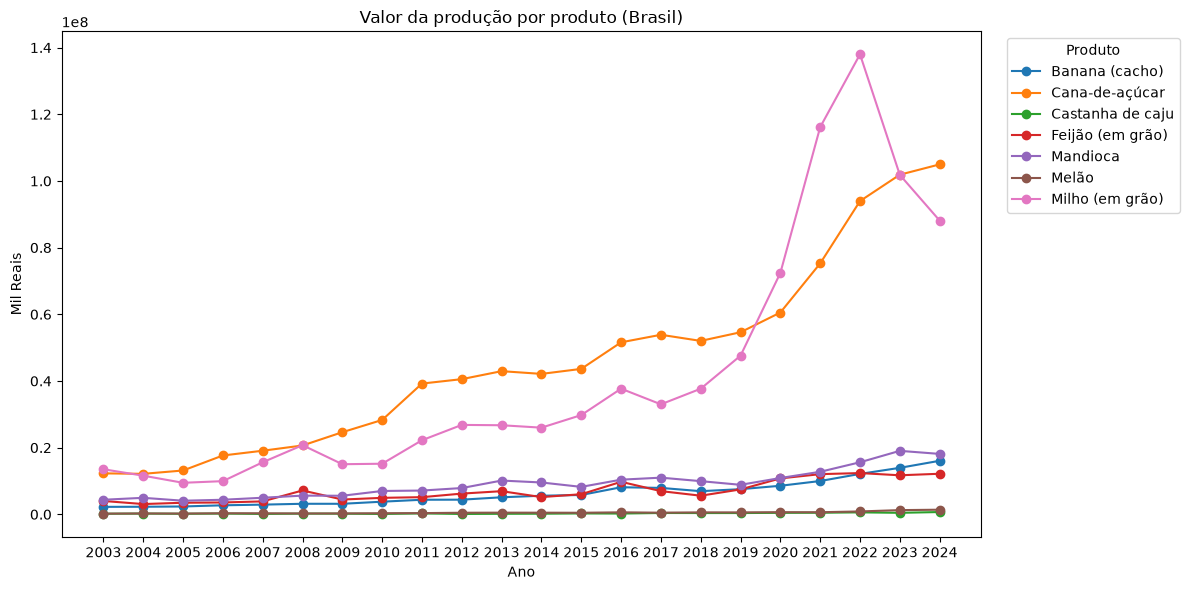

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
projecao_valor_brasil.plot(ax=ax, marker='o')
ax.set_title('Valor da produção por produto (Brasil)')
ax.set_xlabel('Ano')
ax.set_ylabel('Mil Reais')
ax.set_xticks(projecao_valor_brasil.index)
ax.legend(title='Produto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [17]:
print(projecao_valor_brasil)

produto_nome  Banana (cacho)  Cana-de-açúcar  Castanha de caju  Feijão (em grão)    Mandioca      Melão  Milho (em grão)
ano_nome                                                                                                                
2003               2239303.0      12288334.0          173864.0         4008884.0   4372646.0   208145.0       13522976.0
2004               2273680.0      12149902.0          222052.0         3082348.0   4954660.0   260154.0       11595513.0
2005               2355943.0      13148658.0          162610.0         3475946.0   4081973.0   235563.0        9459161.0
2006               2710981.0      17653323.0          228186.0         3557632.0   4373156.0   316236.0        9955266.0
2007               2910157.0      19080325.0          118953.0         3880952.0   4976437.0   315872.0       15616489.0
2008               3165312.0      20650551.0          213299.0         7161004.0   5610590.0   257515.0       20746305.0
2009               3160292.0    

### Ceará

In [18]:
projecao_valor_ceara = df_nome[(df_nome['unidade'] == 'Mil Reais') & (df_nome['territorio_nome'] == 'Ceará')].pivot_table(
    index='ano_nome', columns='produto_nome', values='valor', aggfunc='sum'
)
projecao_valor_ceara

produto_nome,Banana (cacho),Cana-de-açúcar,Castanha de caju,Feijão (em grão),Mandioca,Melão,Milho (em grão)
ano_nome,,,,,,,
2003,103874.0,65040.0,107213.0,221062.0,116101.0,50322.0,282064.0
2004,128250.0,67419.0,115815.0,140506.0,113932.0,84200.0,145449.0
2005,122429.0,61837.0,69140.0,165078.0,93158.0,91745.0,115734.0
2006,156228.0,61712.0,115862.0,244316.0,94356.0,132704.0,268056.0
2007,158182.0,93193.0,43365.0,156038.0,120953.0,139752.0,144272.0
2008,188576.0,98400.0,109244.0,385378.0,144273.0,150887.0,374855.0
2009,193842.0,102363.0,94879.0,186226.0,113777.0,84472.0,220363.0
2010,212454.0,114556.0,54313.0,198191.0,121125.0,103928.0,94585.0
2011,249946.0,118247.0,143946.0,490604.0,175934.0,116980.0,519181.0


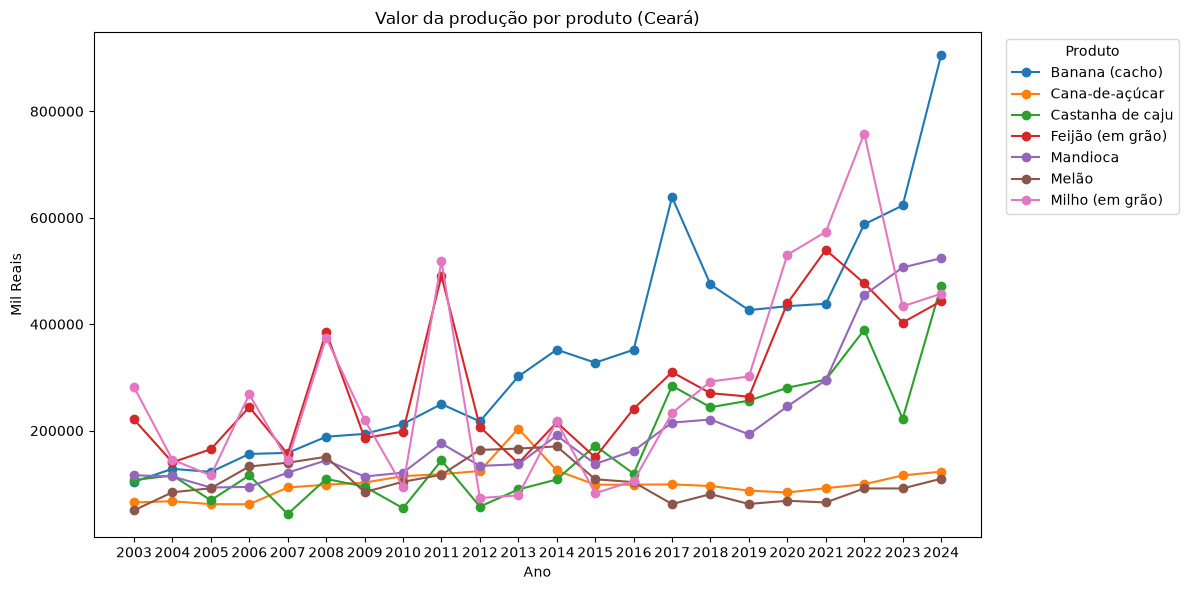

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
projecao_valor_ceara.plot(ax=ax, marker='o')
ax.set_title('Valor da produção por produto (Ceará)')
ax.set_xlabel('Ano')
ax.set_ylabel('Mil Reais')
ax.set_xticks(projecao_valor_ceara.index)
ax.legend(title='Produto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
print(projecao_valor_ceara)

produto_nome  Banana (cacho)  Cana-de-açúcar  Castanha de caju  Feijão (em grão)  Mandioca     Melão  Milho (em grão)
ano_nome                                                                                                             
2003                103874.0         65040.0          107213.0          221062.0  116101.0   50322.0         282064.0
2004                128250.0         67419.0          115815.0          140506.0  113932.0   84200.0         145449.0
2005                122429.0         61837.0           69140.0          165078.0   93158.0   91745.0         115734.0
2006                156228.0         61712.0          115862.0          244316.0   94356.0  132704.0         268056.0
2007                158182.0         93193.0           43365.0          156038.0  120953.0  139752.0         144272.0
2008                188576.0         98400.0          109244.0          385378.0  144273.0  150887.0         374855.0
2009                193842.0        102363.0           9

## Área plantada (Hectares)

### Brasil

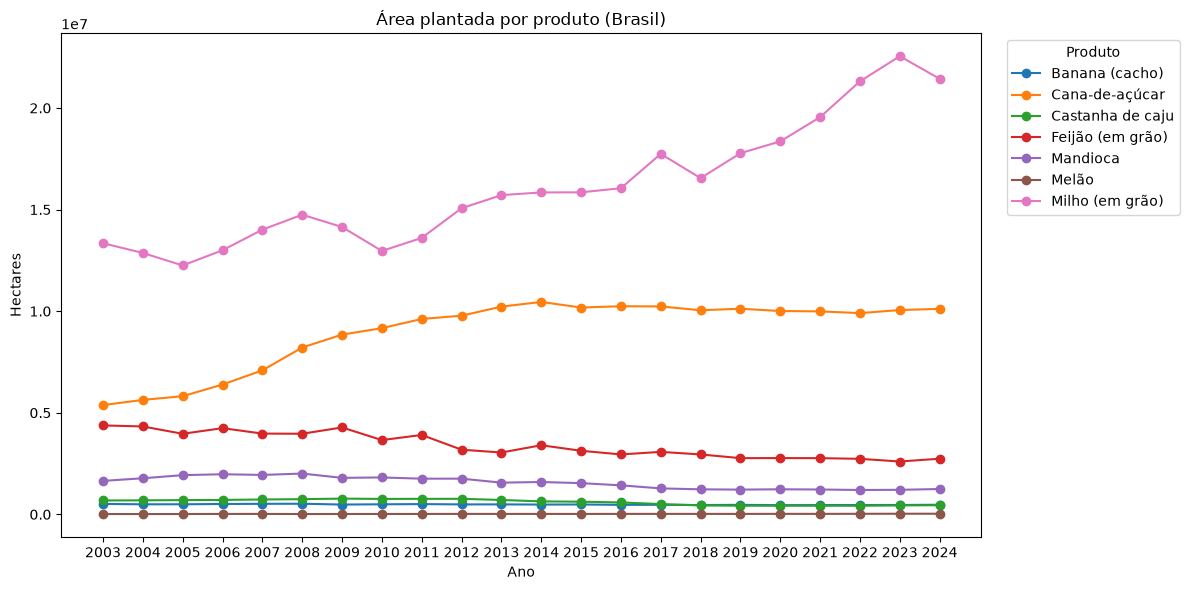

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
projecao_area_plantada_brasil.plot(ax=ax, marker='o')
ax.set_title('Área plantada por produto (Brasil)')
ax.set_xlabel('Ano')
ax.set_ylabel('Hectares')
ax.set_xticks(projecao_area_plantada_brasil.index)
ax.legend(title='Produto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
print(projecao_area_plantada_brasil)

produto_nome  Banana (cacho)  Cana-de-açúcar  Castanha de caju  Feijão (em grão)   Mandioca    Melão  Milho (em grão)
ano_nome                                                                                                             
2003                514549.0       5377216.0          682516.0         4378213.0  1647935.0  16277.0       13343992.0
2004                495385.0       5633700.0          691331.0         4325777.0  1776967.0  15505.0       12864838.0
2005                496287.0       5815151.0          700433.0         3965847.0  1929672.0  16008.0       12249101.0
2006                511181.0       6390474.0          710404.0         4243474.0  1974419.0  21366.0       12997372.0
2007                519187.0       7086851.0          731818.0         3975900.0  1941104.0  22048.0       14010838.0
2008                522867.0       8210877.0          748448.0         3967518.0  2008539.0  15788.0       14747249.0
2009                483532.0       8845833.0          77

### Ceará

In [23]:
projecao_area_plantada_ceara = df_nome[(df_nome['variavel_nome'] == 'Área plantada ou destinada à colheita') & (df_nome['territorio_nome'] == 'Ceará')].pivot_table(
    index='ano_nome', columns='produto_nome', values='valor', aggfunc='sum'
)
projecao_area_plantada_ceara

produto_nome,Banana (cacho),Cana-de-açúcar,Castanha de caju,Feijão (em grão),Mandioca,Melão,Milho (em grão)
ano_nome,,,,,,,
2003,42068.0,33312.0,364601.0,599096.0,82054.0,4119.0,707891.0
2004,42261.0,33972.0,366583.0,566191.0,81043.0,4394.0,655677.0
2005,42120.0,35098.0,368911.0,494132.0,93650.0,4951.0,568753.0
2006,42718.0,29067.0,371032.0,547178.0,88602.0,6629.0,639205.0
2007,42910.0,40098.0,376141.0,561220.0,99654.0,6923.0,679901.0
2008,43694.0,42159.0,386757.0,592716.0,95445.0,6803.0,694054.0
2009,44748.0,42706.0,396538.0,610267.0,103966.0,4888.0,714034.0
2010,46526.0,43024.0,401527.0,464636.0,109155.0,5431.0,551984.0
2011,47745.0,41370.0,402255.0,600137.0,85083.0,5629.0,725301.0


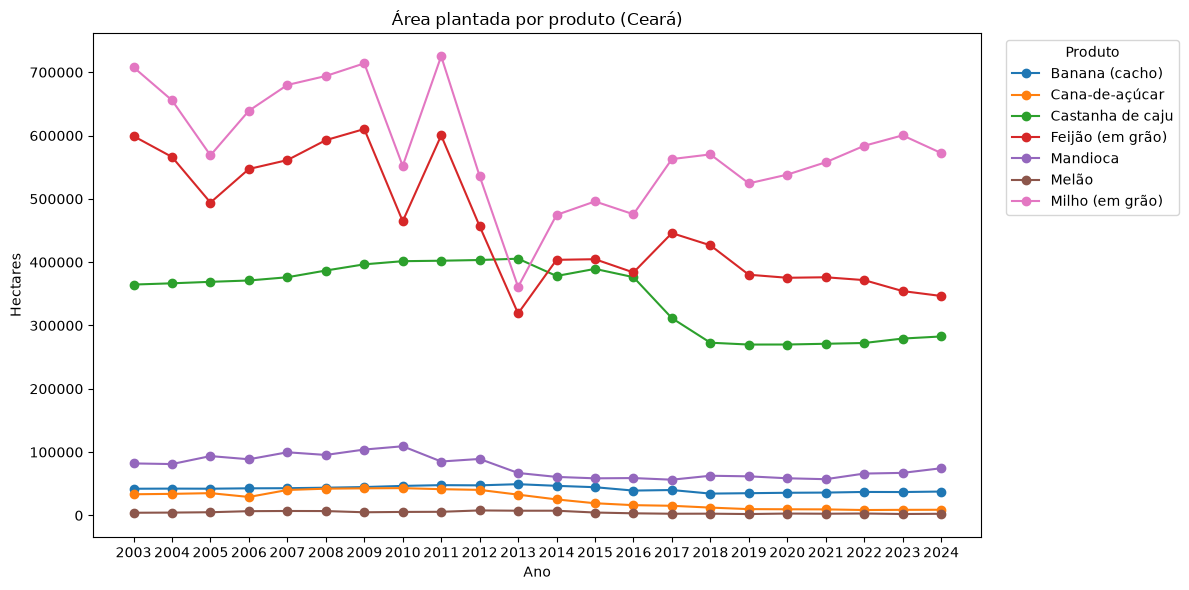

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
projecao_area_plantada_ceara.plot(ax=ax, marker='o')
ax.set_title('Área plantada por produto (Ceará)')
ax.set_xlabel('Ano')
ax.set_ylabel('Hectares')
ax.set_xticks(projecao_area_plantada_ceara.index)
ax.legend(title='Produto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [25]:
print(projecao_area_plantada_ceara)

produto_nome  Banana (cacho)  Cana-de-açúcar  Castanha de caju  Feijão (em grão)  Mandioca   Melão  Milho (em grão)
ano_nome                                                                                                           
2003                 42068.0         33312.0          364601.0          599096.0   82054.0  4119.0         707891.0
2004                 42261.0         33972.0          366583.0          566191.0   81043.0  4394.0         655677.0
2005                 42120.0         35098.0          368911.0          494132.0   93650.0  4951.0         568753.0
2006                 42718.0         29067.0          371032.0          547178.0   88602.0  6629.0         639205.0
2007                 42910.0         40098.0          376141.0          561220.0   99654.0  6923.0         679901.0
2008                 43694.0         42159.0          386757.0          592716.0   95445.0  6803.0         694054.0
2009                 44748.0         42706.0          396538.0          

## Área colhida (Hectares)

### Brasil

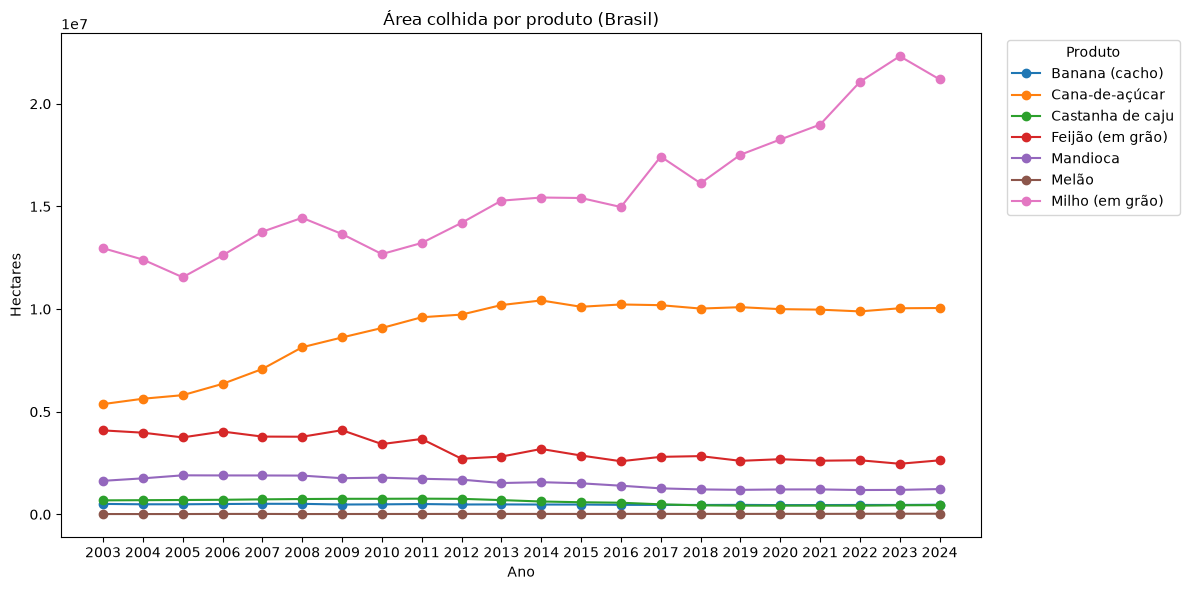

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
projecao_area_colhida_brasil.plot(ax=ax, marker='o')
ax.set_title('Área colhida por produto (Brasil)')
ax.set_xlabel('Ano')
ax.set_ylabel('Hectares')
ax.set_xticks(projecao_area_colhida_brasil.index)
ax.legend(title='Produto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [27]:
print(projecao_area_colhida_brasil)

produto_nome  Banana (cacho)  Cana-de-açúcar  Castanha de caju  Feijão (em grão)   Mandioca    Melão  Milho (em grão)
ano_nome                                                                                                             
2003                509588.0       5371020.0          682503.0         4090568.0  1633568.0  16266.0       12965678.0
2004                491042.0       5631741.0          691059.0         3978660.0  1754875.0  15499.0       12410677.0
2005                491180.0       5805518.0          700367.0         3748656.0  1901535.0  15981.0       11549425.0
2006                504586.0       6355498.0          710181.0         4034383.0  1896509.0  21350.0       12613094.0
2007                515346.0       7080920.0          731412.0         3788279.0  1894458.0  21576.0       13767431.0
2008                513097.0       8140089.0          747434.0         3781908.0  1888859.0  15746.0       14444582.0
2009                479614.0       8617555.0          75

### Ceará

In [28]:
projecao_area_colhida_ceara = df_nome[(df_nome['variavel_nome'] == 'Área colhida') & (df_nome['territorio_nome'] == 'Ceará')].pivot_table(
    index='ano_nome', columns='produto_nome', values='valor', aggfunc='sum'
)
projecao_area_colhida_ceara

produto_nome,Banana (cacho),Cana-de-açúcar,Castanha de caju,Feijão (em grão),Mandioca,Melão,Milho (em grão)
ano_nome,,,,,,,
2003,42068.0,33312.0,364601.0,599096.0,82054.0,4119.0,707891.0
2004,42261.0,33972.0,366583.0,548688.0,81043.0,4394.0,655677.0
2005,42120.0,35098.0,368911.0,492350.0,93650.0,4951.0,566846.0
2006,42718.0,29067.0,371032.0,547178.0,88602.0,6629.0,639205.0
2007,42910.0,40098.0,376132.0,558270.0,99654.0,6923.0,674041.0
2008,43511.0,42159.0,386757.0,576469.0,95445.0,6803.0,675480.0
2009,44742.0,42706.0,396538.0,586525.0,103707.0,4888.0,691632.0
2010,46220.0,43024.0,401347.0,464636.0,109155.0,5431.0,551984.0
2011,47745.0,41370.0,402255.0,600137.0,85083.0,5629.0,725301.0


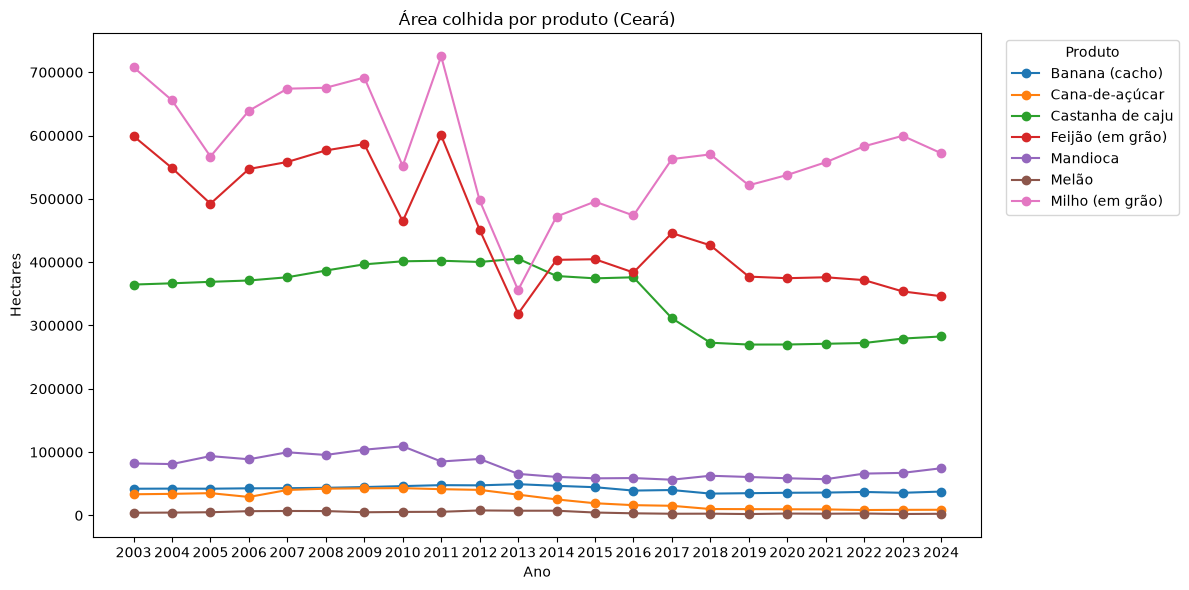

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
projecao_area_colhida_ceara.plot(ax=ax, marker='o')
ax.set_title('Área colhida por produto (Ceará)')
ax.set_xlabel('Ano')
ax.set_ylabel('Hectares')
ax.set_xticks(projecao_area_colhida_ceara.index)
ax.legend(title='Produto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [30]:
print(projecao_area_colhida_ceara)

produto_nome  Banana (cacho)  Cana-de-açúcar  Castanha de caju  Feijão (em grão)  Mandioca   Melão  Milho (em grão)
ano_nome                                                                                                           
2003                 42068.0         33312.0          364601.0          599096.0   82054.0  4119.0         707891.0
2004                 42261.0         33972.0          366583.0          548688.0   81043.0  4394.0         655677.0
2005                 42120.0         35098.0          368911.0          492350.0   93650.0  4951.0         566846.0
2006                 42718.0         29067.0          371032.0          547178.0   88602.0  6629.0         639205.0
2007                 42910.0         40098.0          376132.0          558270.0   99654.0  6923.0         674041.0
2008                 43511.0         42159.0          386757.0          576469.0   95445.0  6803.0         675480.0
2009                 44742.0         42706.0          396538.0          

## Quantidade produzida (Toneladas)

### Brasil

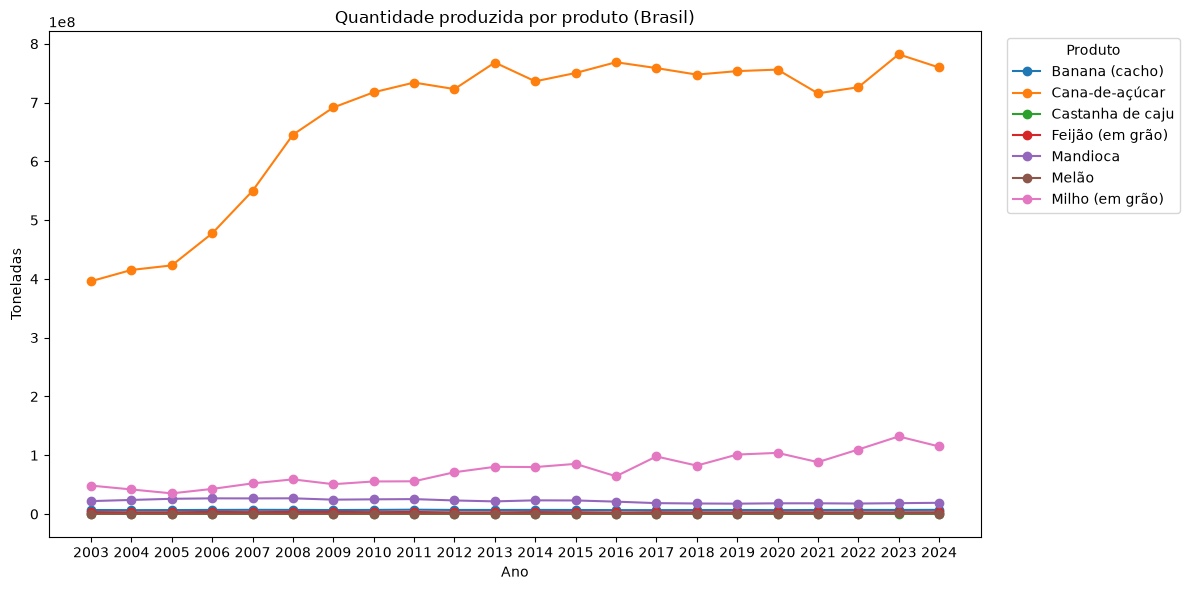

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
projecao_producao_brasil.plot(ax=ax, marker='o')
ax.set_title('Quantidade produzida por produto (Brasil)')
ax.set_xlabel('Ano')
ax.set_ylabel('Toneladas')
ax.set_xticks(projecao_producao_brasil.index)
ax.legend(title='Produto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [32]:
print(projecao_producao_brasil)

produto_nome  Banana (cacho)  Cana-de-açúcar  Castanha de caju  Feijão (em grão)    Mandioca     Melão  Milho (em grão)
ano_nome                                                                                                               
2003               6800981.0     396012158.0          183094.0         3302038.0  21961082.0  349498.0       48327323.0
2004               6583564.0     415205835.0          187839.0         2967007.0  23926553.0  340863.0       41787558.0
2005               6703400.0     422956646.0          152751.0         3021641.0  25872015.0  352742.0       35113312.0
2006               6956179.0     477410655.0          243770.0         3457744.0  26639013.0  500021.0       42661677.0
2007               7098353.0     549707314.0          140675.0         3169356.0  26541200.0  495323.0       52112217.0
2008               6998150.0     645300182.0          243253.0         3461194.0  26703039.0  340464.0       58933347.0
2009               6783490.0     6916061

### Ceará

In [33]:
projecao_producao_ceara = df_nome[(df_nome['unidade'] == 'Toneladas') & (df_nome['territorio_nome'] == 'Ceará')].pivot_table(
    index='ano_nome', columns='produto_nome', values='valor', aggfunc='sum'
)
projecao_producao_ceara

produto_nome,Banana (cacho),Cana-de-açúcar,Castanha de caju,Feijão (em grão),Mandioca,Melão,Milho (em grão)
ano_nome,,,,,,,
2003,341715.0,1742801.0,108051.0,208792.0,757891.0,99496.0,745317.0
2004,367667.0,1762197.0,86576.0,129821.0,754575.0,109566.0,379837.0
2005,363025.0,1787126.0,66090.0,132366.0,826017.0,117937.0,281713.0
2006,408026.0,1617003.0,130544.0,253258.0,860780.0,165633.0,760231.0
2007,385455.0,2251239.0,53420.0,129512.0,749479.0,173378.0,357342.0
2008,423016.0,2270816.0,121045.0,252741.0,925317.0,170424.0,752882.0
2009,429506.0,2323937.0,104421.0,129827.0,686325.0,124157.0,538962.0
2010,445169.0,2306004.0,39596.0,83286.0,620964.0,153161.0,174955.0
2011,494250.0,2209852.0,111718.0,264205.0,836606.0,143466.0,915286.0


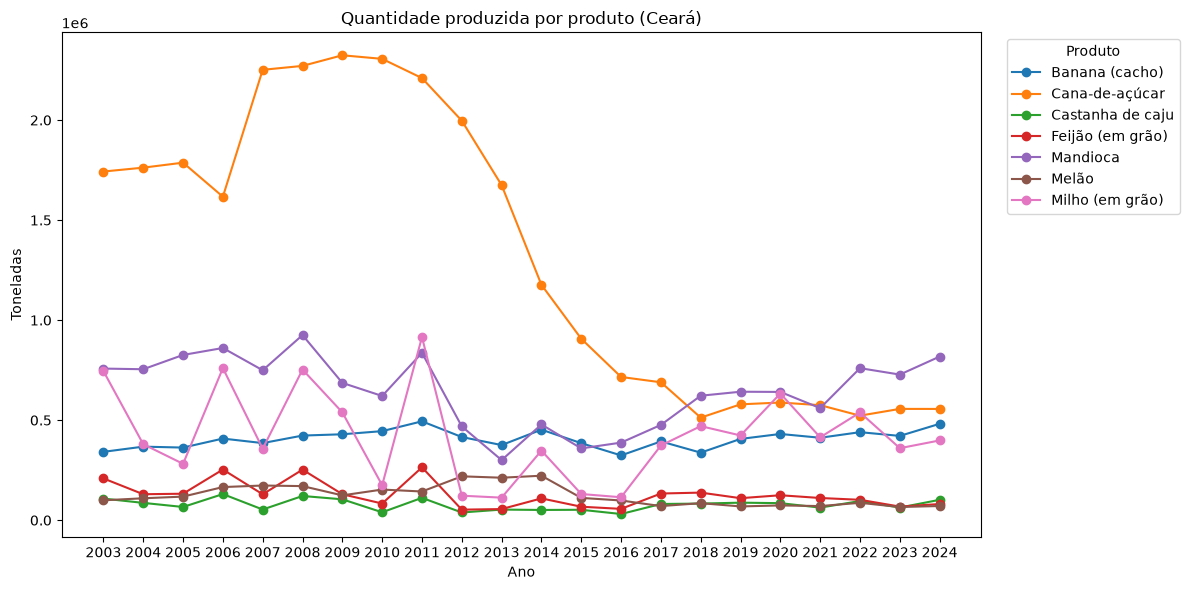

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))
projecao_producao_ceara.plot(ax=ax, marker='o')
ax.set_title('Quantidade produzida por produto (Ceará)')
ax.set_xlabel('Ano')
ax.set_ylabel('Toneladas')
ax.set_xticks(projecao_producao_ceara.index)
ax.legend(title='Produto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [35]:
print(projecao_producao_ceara)

produto_nome  Banana (cacho)  Cana-de-açúcar  Castanha de caju  Feijão (em grão)  Mandioca     Melão  Milho (em grão)
ano_nome                                                                                                             
2003                341715.0       1742801.0          108051.0          208792.0  757891.0   99496.0         745317.0
2004                367667.0       1762197.0           86576.0          129821.0  754575.0  109566.0         379837.0
2005                363025.0       1787126.0           66090.0          132366.0  826017.0  117937.0         281713.0
2006                408026.0       1617003.0          130544.0          253258.0  860780.0  165633.0         760231.0
2007                385455.0       2251239.0           53420.0          129512.0  749479.0  173378.0         357342.0
2008                423016.0       2270816.0          121045.0          252741.0  925317.0  170424.0         752882.0
2009                429506.0       2323937.0          10

## Rendimento médio (Quilogramas por Hectare)

### Brasil

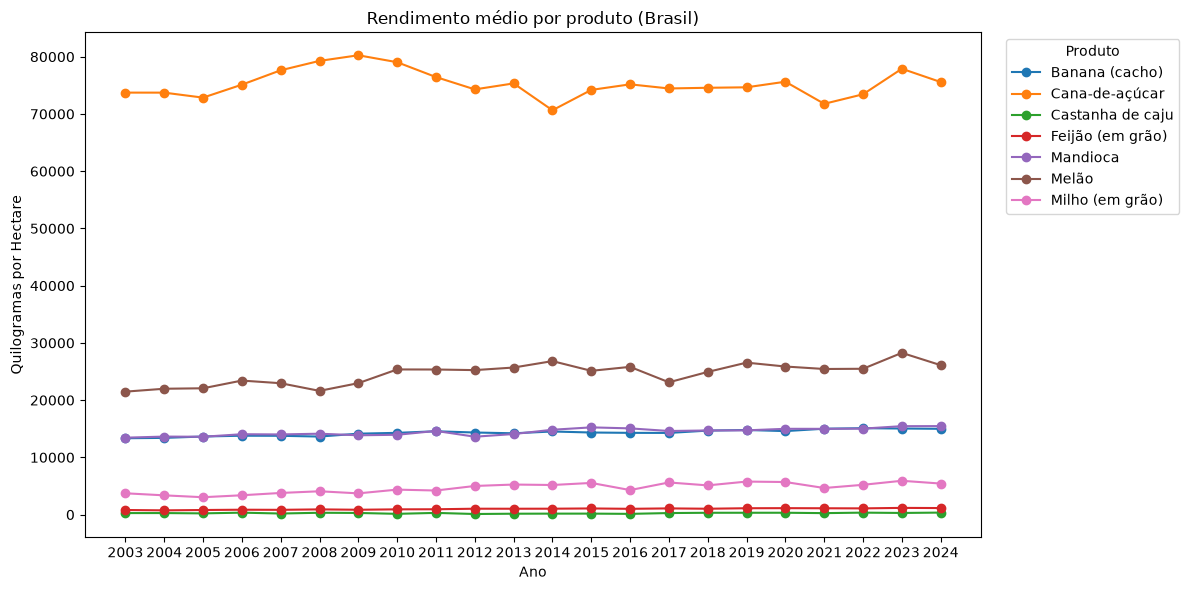

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))
projecao_rendimento_brasil.plot(ax=ax, marker='o')
ax.set_title('Rendimento médio por produto (Brasil)')
ax.set_xlabel('Ano')
ax.set_ylabel('Quilogramas por Hectare')
ax.set_xticks(projecao_rendimento_brasil.index)
ax.legend(title='Produto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [37]:
print(projecao_rendimento_brasil)

produto_nome  Banana (cacho)  Cana-de-açúcar  Castanha de caju  Feijão (em grão)  Mandioca    Melão  Milho (em grão)
ano_nome                                                                                                            
2003                 13346.0         73731.0             268.0             807.0   13443.0  21486.0           3727.0
2004                 13407.0         73726.0             271.0             745.0   13634.0  21992.0           3367.0
2005                 13647.0         72854.0             218.0             806.0   13605.0  22072.0           3040.0
2006                 13785.0         75117.0             343.0             857.0   14046.0  23420.0           3382.0
2007                 13773.0         77632.0             192.0             836.0   14009.0  22957.0           3785.0
2008                 13639.0         79274.0             325.0             915.0   14137.0  21622.0           4079.0
2009                 14143.0         80255.0             290.0  

### Ceará

In [38]:
projecao_rendimento_ceara = df_nome[(df_nome['unidade'] == 'Quilogramas por Hectare') & (df_nome['territorio_nome'] == 'Ceará')].pivot_table(
    index='ano_nome', columns='produto_nome', values='valor', aggfunc='sum'
)
projecao_rendimento_ceara

produto_nome,Banana (cacho),Cana-de-açúcar,Castanha de caju,Feijão (em grão),Mandioca,Melão,Milho (em grão)
ano_nome,,,,,,,
2003,8122.0,52317.0,296.0,348.0,9236.0,24155.0,1052.0
2004,8699.0,51872.0,236.0,236.0,9310.0,24935.0,579.0
2005,8618.0,50918.0,179.0,268.0,8820.0,23820.0,496.0
2006,9551.0,55630.0,351.0,462.0,9715.0,24986.0,1189.0
2007,8982.0,56143.0,142.0,231.0,7520.0,25043.0,530.0
2008,9722.0,53863.0,312.0,438.0,9694.0,25051.0,1114.0
2009,9599.0,54417.0,263.0,221.0,6617.0,25400.0,779.0
2010,9631.0,53598.0,98.0,179.0,5688.0,28201.0,316.0
2011,10352.0,53417.0,278.0,440.0,9833.0,25487.0,1262.0


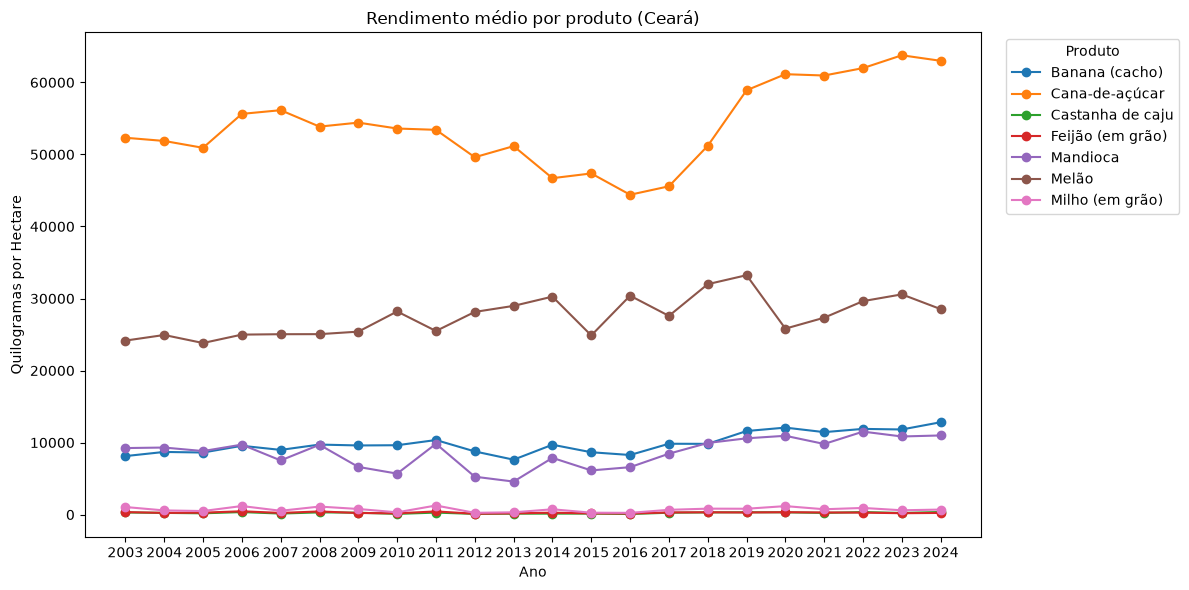

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))
projecao_rendimento_ceara.plot(ax=ax, marker='o')
ax.set_title('Rendimento médio por produto (Ceará)')
ax.set_xlabel('Ano')
ax.set_ylabel('Quilogramas por Hectare')
ax.set_xticks(projecao_rendimento_ceara.index)
ax.legend(title='Produto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [40]:
print(projecao_rendimento_ceara)

produto_nome  Banana (cacho)  Cana-de-açúcar  Castanha de caju  Feijão (em grão)  Mandioca    Melão  Milho (em grão)
ano_nome                                                                                                            
2003                  8122.0         52317.0             296.0             348.0    9236.0  24155.0           1052.0
2004                  8699.0         51872.0             236.0             236.0    9310.0  24935.0            579.0
2005                  8618.0         50918.0             179.0             268.0    8820.0  23820.0            496.0
2006                  9551.0         55630.0             351.0             462.0    9715.0  24986.0           1189.0
2007                  8982.0         56143.0             142.0             231.0    7520.0  25043.0            530.0
2008                  9722.0         53863.0             312.0             438.0    9694.0  25051.0           1114.0
2009                  9599.0         54417.0             263.0  

## Participação do Ceará no Brasil (%)

### Valor da produção

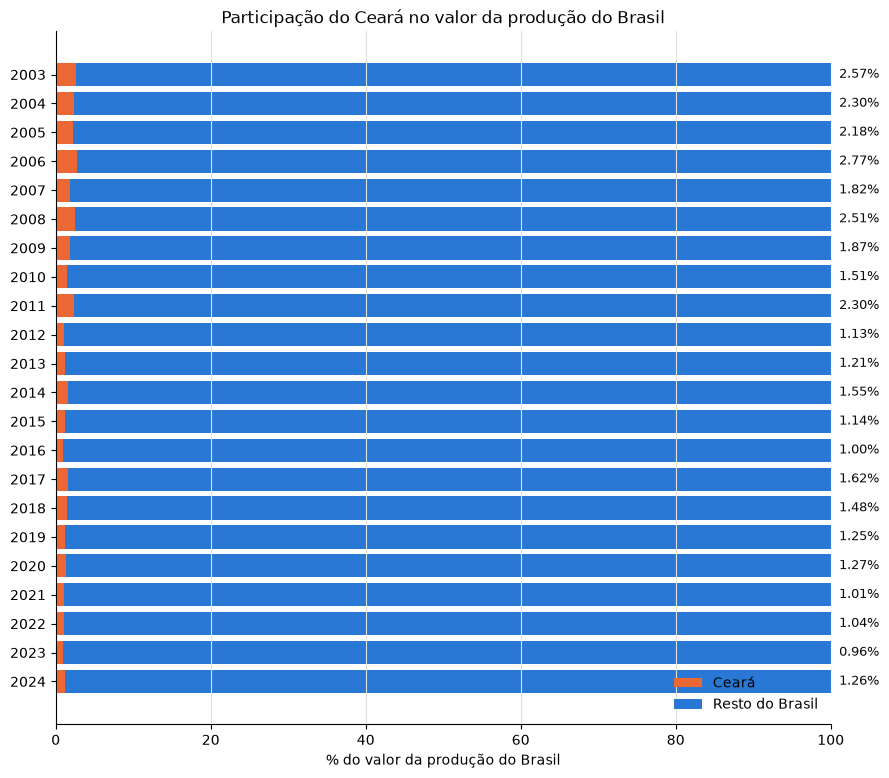

ano_nome
2003    2.568784
2004    2.303445
2005    2.184460
2006    2.766439
2007    1.824669
2008    2.511242
2009    1.868304
2010    1.506649
2011    2.304534
2012    1.130044
2013    1.205485
2014    1.548424
2015    1.142154
2016    0.998002
2017    1.620838
2018    1.483607
2019    1.252344
2020    1.267142
2021    1.011411
2022    1.044715
2023    0.957933
2024    1.256389
dtype: float64


In [41]:
cores = {"Brasil": "#2a78d6", "Ceará": "#eb6834"}

percentual_valor = (projecao_valor_ceara.sum(axis=1) / projecao_valor_brasil.sum(axis=1)) * 100
resto_valor = 100 - percentual_valor

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(percentual_valor.index, percentual_valor, color=cores["Ceará"], label="Ceará")
ax.barh(percentual_valor.index, resto_valor, left=percentual_valor, color=cores["Brasil"], label="Resto do Brasil")

for ano, pct in percentual_valor.items():
    ax.annotate(
        f"{pct:.2f}%",
        (100, ano),
        textcoords="offset points", xytext=(6, 0), va="center", ha="left", fontsize=9, color="#0b0b0b",
    )

ax.set_yticks(percentual_valor.index)
ax.invert_yaxis()
ax.set_xlabel("% do valor da produção do Brasil")
ax.set_title("Participação do Ceará no valor da produção do Brasil")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")

plt.show()

print(percentual_valor)

### Área plantada

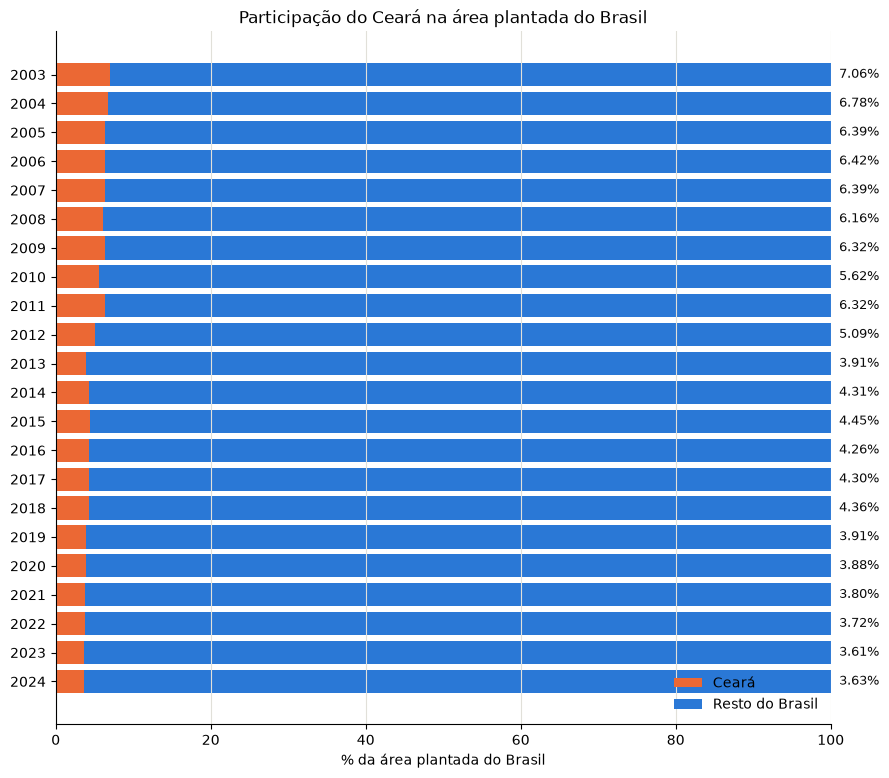

ano_nome
2003    7.061216
2004    6.782494
2005    6.386394
2006    6.422775
2007    6.387384
2008    6.159989
2009    6.318645
2010    5.618361
2011    6.321223
2012    5.088865
2013    3.909146
2014    4.305128
2015    4.450979
2016    4.261337
2017    4.304003
2018    4.358033
2019    3.912144
2020    3.877678
2021    3.804436
2022    3.721697
2023    3.611356
2024    3.630723
dtype: float64


In [42]:
percentual_area_plantada = (projecao_area_plantada_ceara.sum(axis=1) / projecao_area_plantada_brasil.sum(axis=1)) * 100
resto_area_plantada = 100 - percentual_area_plantada

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(percentual_area_plantada.index, percentual_area_plantada, color=cores["Ceará"], label="Ceará")
ax.barh(percentual_area_plantada.index, resto_area_plantada, left=percentual_area_plantada, color=cores["Brasil"], label="Resto do Brasil")

for ano, pct in percentual_area_plantada.items():
    ax.annotate(
        f"{pct:.2f}%",
        (100, ano),
        textcoords="offset points", xytext=(6, 0), va="center", ha="left", fontsize=9, color="#0b0b0b",
    )

ax.set_yticks(percentual_area_plantada.index)
ax.invert_yaxis()
ax.set_xlabel("% da área plantada do Brasil")
ax.set_title("Participação do Ceará na área plantada do Brasil")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")

plt.show()

print(percentual_area_plantada)

### Área colhida

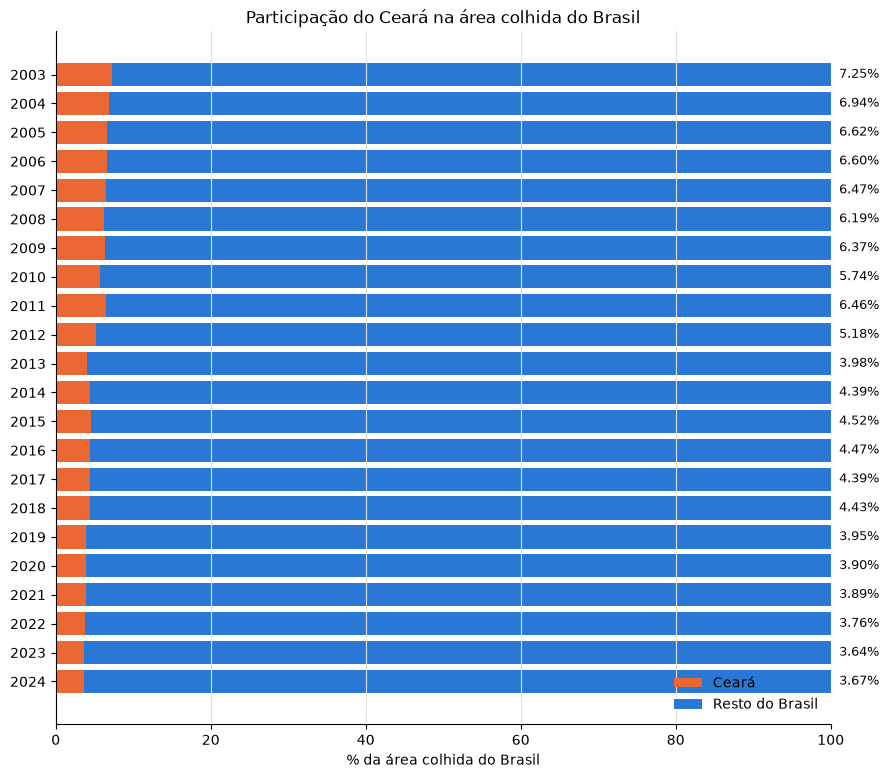

ano_nome
2003    7.254451
2004    6.937811
2005    6.624327
2006    6.598015
2007    6.467861
2008    6.185296
2009    6.365635
2010    5.743998
2011    6.463008
2012    5.182557
2013    3.980623
2014    4.391939
2015    4.521967
2016    4.468096
2017    4.391463
2018    4.431260
2019    3.947870
2020    3.899155
2021    3.888855
2022    3.758704
2023    3.644243
2024    3.673166
dtype: float64


In [43]:
percentual_area_colhida = (projecao_area_colhida_ceara.sum(axis=1) / projecao_area_colhida_brasil.sum(axis=1)) * 100
resto_area_colhida = 100 - percentual_area_colhida

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(percentual_area_colhida.index, percentual_area_colhida, color=cores["Ceará"], label="Ceará")
ax.barh(percentual_area_colhida.index, resto_area_colhida, left=percentual_area_colhida, color=cores["Brasil"], label="Resto do Brasil")

for ano, pct in percentual_area_colhida.items():
    ax.annotate(
        f"{pct:.2f}%",
        (100, ano),
        textcoords="offset points", xytext=(6, 0), va="center", ha="left", fontsize=9, color="#0b0b0b",
    )

ax.set_yticks(percentual_area_colhida.index)
ax.invert_yaxis()
ax.set_xlabel("% da área colhida do Brasil")
ax.set_title("Participação do Ceará na área colhida do Brasil")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")

plt.show()

print(percentual_area_colhida)

### Quantidade produzida

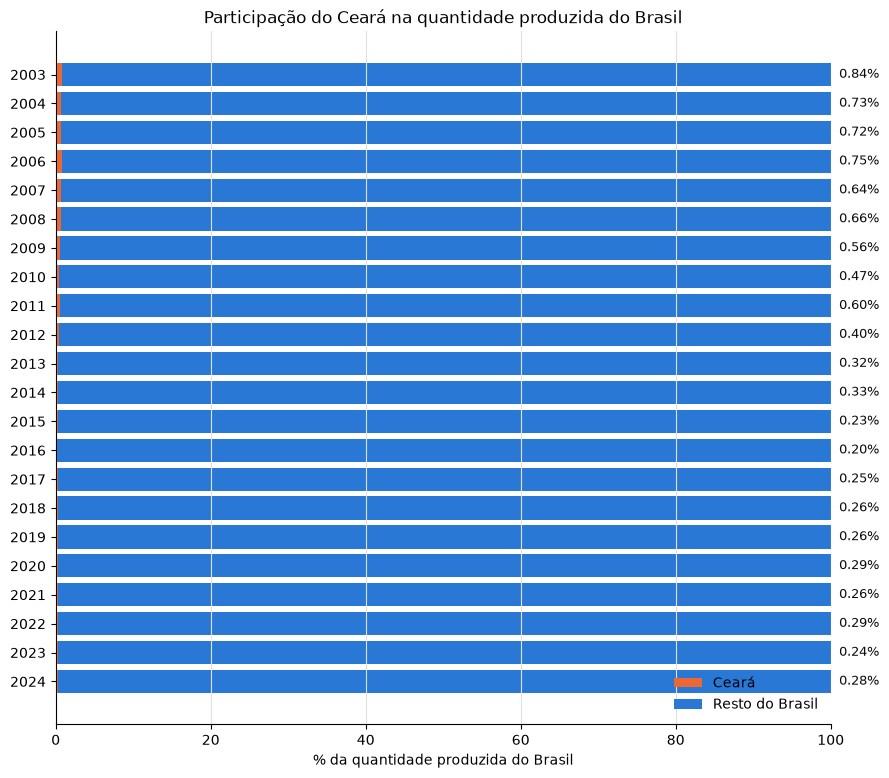

ano_nome
2003    0.839539
2004    0.731211
2005    0.723285
2006    0.752054
2007    0.641335
2008    0.662584
2009    0.557742
2010    0.472864
2011    0.601974
2012    0.400579
2013    0.316301
2014    0.333801
2015    0.231551
2016    0.200113
2017    0.250501
2018    0.262054
2019    0.262604
2020    0.290026
2021    0.264996
2022    0.294553
2023    0.239894
2024    0.277230
dtype: float64


In [44]:
percentual_producao = (projecao_producao_ceara.sum(axis=1) / projecao_producao_brasil.sum(axis=1)) * 100
resto_producao = 100 - percentual_producao

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(percentual_producao.index, percentual_producao, color=cores["Ceará"], label="Ceará")
ax.barh(percentual_producao.index, resto_producao, left=percentual_producao, color=cores["Brasil"], label="Resto do Brasil")

for ano, pct in percentual_producao.items():
    ax.annotate(
        f"{pct:.2f}%",
        (100, ano),
        textcoords="offset points", xytext=(6, 0), va="center", ha="left", fontsize=9, color="#0b0b0b",
    )

ax.set_yticks(percentual_producao.index)
ax.invert_yaxis()
ax.set_xlabel("% da quantidade produzida do Brasil")
ax.set_title("Participação do Ceará na quantidade produzida do Brasil")
ax.set_xlim(0, 100)
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")

plt.show()

print(percentual_producao)

## Análise por Município

### Valor da produção

In [45]:
pivot_municipios_valor = df_nome[
    (df_nome['unidade'] == 'Mil Reais') & (~df_nome['territorio_nome'].isin(['Brasil', 'Ceará']))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')
pivot_municipios_valor

territorio_nome,Abaiara - CE,Acarape - CE,Acaraú - CE,Acopiara - CE,Aiuaba - CE,Alcântaras - CE,Altaneira - CE,Alto Santo - CE,Amontada - CE,Antonina do Norte - CE,Apuiarés - CE,Aquiraz - CE,Aracati - CE,Aracoiaba - CE,Ararendá - CE,Araripe - CE,Aratuba - CE,Arneiroz - CE,Assaré - CE,Aurora - CE,Baixio - CE,Banabuiú - CE,Barbalha - CE,Barreira - CE,Barro - CE,Barroquinha - CE,Baturité - CE,Beberibe - CE,Bela Cruz - CE,Boa Viagem - CE,Brejo Santo - CE,Camocim - CE,Campos Sales - CE,Canindé - CE,Capistrano - CE,Caridade - CE,Caririaçu - CE,Cariré - CE,Cariús - CE,Carnaubal - CE,Cascavel - CE,Catarina - CE,Catunda - CE,Caucaia - CE,Cedro - CE,Chaval - CE,Chorozinho - CE,Choró - CE,Coreaú - CE,Crateús - CE,Crato - CE,Croatá - CE,Cruz - CE,Deputado Irapuan Pinheiro - CE,Ereré - CE,Eusébio - CE,Farias Brito - CE,Forquilha - CE,Fortaleza - CE,Fortim - CE,Frecheirinha - CE,General Sampaio - CE,Granja - CE,Granjeiro - CE,Graça - CE,Groaíras - CE,Guaiúba - CE,Guaraciaba do Norte - CE,Guaramiranga - CE,Hidrolândia - CE,Horizonte - CE,Ibaretama - CE,Ibiapina - CE,Ibicuitinga - CE,Icapuí - CE,Icó - CE,Iguatu - CE,Independência - CE,Ipaporanga - CE,Ipaumirim - CE,Ipu - CE,Ipueiras - CE,Iracema - CE,Irauçuba - CE,Itaitinga - CE,Itaiçaba - CE,Itapajé - CE,Itapipoca - CE,Itapiúna - CE,Itarema - CE,Itatira - CE,Jaguaretama - CE,Jaguaribara - CE,Jaguaribe - CE,Jaguaruana - CE,Jardim - CE,Jati - CE,Jijoca de Jericoacoara - CE,Juazeiro do Norte - CE,Jucás - CE,Lavras da Mangabeira - CE,Limoeiro do Norte - CE,Madalena - CE,Maracanaú - CE,Maranguape - CE,Marco - CE,Martinópole - CE,Massapê - CE,Mauriti - CE,Meruoca - CE,Milagres - CE,Milhã - CE,Miraíma - CE,Missão Velha - CE,Mombaça - CE,Monsenhor Tabosa - CE,Morada Nova - CE,Moraújo - CE,Morrinhos - CE,Mucambo - CE,Mulungu - CE,Nova Olinda - CE,Nova Russas - CE,Novo Oriente - CE,Ocara - CE,Orós - CE,Pacajus - CE,Pacatuba - CE,Pacoti - CE,Pacujá - CE,Palhano - CE,Palmácia - CE,Paracuru - CE,Paraipaba - CE,Parambu - CE,Paramoti - CE,Pedra Branca - CE,Penaforte - CE,Pentecoste - CE,Pereiro - CE,Pindoretama - CE,Piquet Carneiro - CE,Pires Ferreira - CE,Poranga - CE,Porteiras - CE,Potengi - CE,Potiretama - CE,Quiterianópolis - CE,Quixadá - CE,Quixelô - CE,Quixeramobim - CE,Quixeré - CE,Redenção - CE,Reriutaba - CE,Russas - CE,Saboeiro - CE,Salitre - CE,Santa Quitéria - CE,Santana do Acaraú - CE,Santana do Cariri - CE,Senador Pompeu - CE,Senador Sá - CE,Sobral - CE,Solonópole - CE,São Benedito - CE,São Gonçalo do Amarante - CE,São João do Jaguaribe - CE,São Luís do Curu - CE,Tabuleiro do Norte - CE,Tamboril - CE,Tarrafas - CE,Tauá - CE,Tejuçuoca - CE,Tianguá - CE,Trairi - CE,Tururu - CE,Ubajara - CE,Umari - CE,Umirim - CE,Uruburetama - CE,Uruoca - CE,Varjota - CE,Viçosa do Ceará - CE,Várzea Alegre - CE
ano_nome,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003,3093.0,1589.0,10595.0,5352.0,2808.0,3084.0,630.0,3341.0,9832.0,594.0,590.0,3269.0,19053.0,4825.0,2338.0,11976.0,5225.0,1036.0,3380.0,9193.0,966.0,2134.0,6639.0,5269.0,6431.0,2392.0,8601.0,13803.0,12853.0,15430.0,16447.0,3232.0,6570.0,11792.0,6506.0,1731.0,5228.0,6490.0,2162.0,1260.0,7885.0,1233.0,2080.0,4631.0,2783.0,1349.0,6924.0,3079.0,1719.0,19270.0,5244.0,3192.0,6638.0,2246.0,844.0,383.0,1929.0,3016.0,162.0,3063.0,2431.0,341.0,3757.0,677.0,2165.0,1275.0,1721.0,7915.0,1235.0,4232.0,2949.0,5354.0,13915.0,3442.0,4869.0,9371.0,8282.0,5050.0,4718.0,1681.0,8939.0,5925.0,523.0,1522.0,535.0,3639.0,9111.0,19427.0,3924.0,7571.0,6707.0,5695.0,1017.0,3058.0,4142.0,4802.0,2018.0,2787.0,1079.0,3292.0,3786.0,13542.0,7122.0,830.0,3932.0,5764.0,1158.0,7615.0,17563.0,2932.0,11724.0,2637.0,779.0,8642.0,5064.0,3352.0,7488.0,847.0,8148.0,2746.0,3622.0,1177.0,2561.0,8753.0,7603.0,1862.0,12551.0,1140.0,2939.0,1398.0,1926.0,2335.0,6745.0,8781.0,14383.0,1555.0,9672.0,1605.0,1365.0,3404.0,1640.0,1824.0,2533.0,1254.0,7154.0,2419.0,120

In [46]:
total_municipios_valor = pivot_municipios_valor.sum(axis=0).sort_values(ascending=False)
top8_melhores_valor = total_municipios_valor.head(8)
top8_piores_valor = total_municipios_valor.tail(8).sort_values()

print("Top 8 melhores municípios - Valor da produção (soma 2003-2024):")
print(top8_melhores_valor)
print()
print("Top 8 piores municípios - Valor da produção (soma 2003-2024):")
print(top8_piores_valor)

Top 8 melhores municípios - Valor da produção (soma 2003-2024):
territorio_nome
Quixeré - CE              1344855.0
Limoeiro do Norte - CE    1288799.0
Missão Velha - CE          793036.0
Icapuí - CE                769213.0
Aracati - CE               713038.0
São Benedito - CE          680098.0
Itapipoca - CE             672856.0
Bela Cruz - CE             640525.0
dtype: float64

Top 8 piores municípios - Valor da produção (soma 2003-2024):
territorio_nome
Fortaleza - CE             2417.0
Eusébio - CE               7050.0
Antonina do Norte - CE    14809.0
Moraújo - CE              15228.0
Baixio - CE               15905.0
Pacujá - CE               17036.0
Maracanaú - CE            17083.0
Iracema - CE              19574.0
dtype: float64


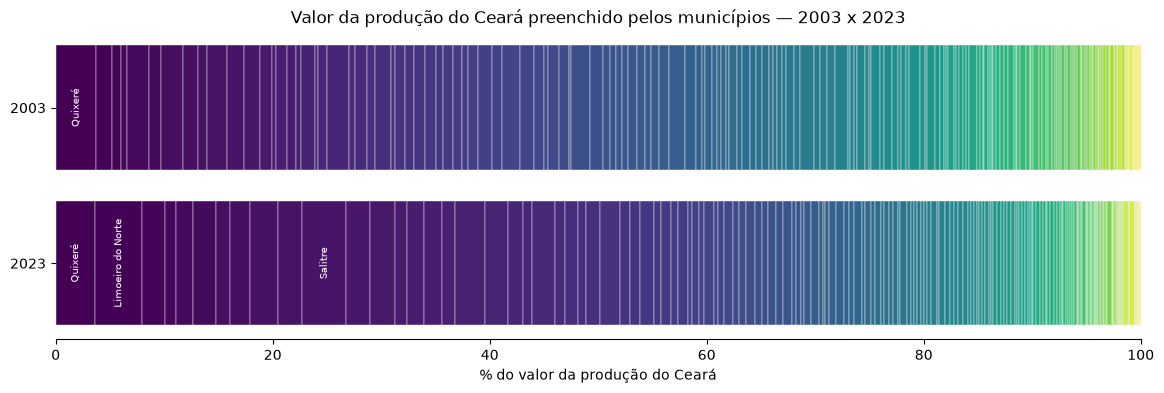

In [47]:
participacao_municipios_valor = pivot_municipios_valor.div(pivot_municipios_valor.sum(axis=1), axis=0) * 100
ordem_municipios_valor = total_municipios_valor.index
cmap_municipios = plt.colormaps["viridis"]
n_municipios = len(ordem_municipios_valor)
cor_por_municipio_valor = {m: cmap_municipios(i / n_municipios) for i, m in enumerate(ordem_municipios_valor)}

anos_resumo = [2003, 2023]

fig, ax = plt.subplots(figsize=(14, 4))
for ano in anos_resumo:
    esquerda = 0
    for municipio in ordem_municipios_valor:
        pct = participacao_municipios_valor.loc[ano, municipio]
        ax.barh(str(ano), pct, left=esquerda, color=cor_por_municipio_valor[municipio], edgecolor="#fcfcfb", linewidth=0.3)
        if pct > 3:
            ax.text(esquerda + pct / 2, str(ano), municipio.replace(" - CE", ""), ha="center", va="center", fontsize=7, color="white", rotation=90)
        esquerda += pct

ax.invert_yaxis()
ax.set_xlabel("% do valor da produção do Ceará")
ax.set_title("Valor da produção do Ceará preenchido pelos municípios — 2003 x 2023")
ax.set_xlim(0, 100)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.show()

### Área plantada

In [48]:
pivot_municipios_area_plantada = df_nome[
    (df_nome['variavel_nome'] == 'Área plantada ou destinada à colheita') & (~df_nome['territorio_nome'].isin(['Brasil', 'Ceará']))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')
pivot_municipios_area_plantada

territorio_nome,Abaiara - CE,Acarape - CE,Acaraú - CE,Acopiara - CE,Aiuaba - CE,Alcântaras - CE,Altaneira - CE,Alto Santo - CE,Amontada - CE,Antonina do Norte - CE,Apuiarés - CE,Aquiraz - CE,Aracati - CE,Aracoiaba - CE,Ararendá - CE,Araripe - CE,Aratuba - CE,Arneiroz - CE,Assaré - CE,Aurora - CE,Baixio - CE,Banabuiú - CE,Barbalha - CE,Barreira - CE,Barro - CE,Barroquinha - CE,Baturité - CE,Beberibe - CE,Bela Cruz - CE,Boa Viagem - CE,Brejo Santo - CE,Camocim - CE,Campos Sales - CE,Canindé - CE,Capistrano - CE,Caridade - CE,Caririaçu - CE,Cariré - CE,Cariús - CE,Carnaubal - CE,Cascavel - CE,Catarina - CE,Catunda - CE,Caucaia - CE,Cedro - CE,Chaval - CE,Chorozinho - CE,Choró - CE,Coreaú - CE,Crateús - CE,Crato - CE,Croatá - CE,Cruz - CE,Deputado Irapuan Pinheiro - CE,Ereré - CE,Eusébio - CE,Farias Brito - CE,Forquilha - CE,Fortaleza - CE,Fortim - CE,Frecheirinha - CE,General Sampaio - CE,Granja - CE,Granjeiro - CE,Graça - CE,Groaíras - CE,Guaiúba - CE,Guaraciaba do Norte - CE,Guaramiranga - CE,Hidrolândia - CE,Horizonte - CE,Ibaretama - CE,Ibiapina - CE,Ibicuitinga - CE,Icapuí - CE,Icó - CE,Iguatu - CE,Independência - CE,Ipaporanga - CE,Ipaumirim - CE,Ipu - CE,Ipueiras - CE,Iracema - CE,Irauçuba - CE,Itaitinga - CE,Itaiçaba - CE,Itapajé - CE,Itapipoca - CE,Itapiúna - CE,Itarema - CE,Itatira - CE,Jaguaretama - CE,Jaguaribara - CE,Jaguaribe - CE,Jaguaruana - CE,Jardim - CE,Jati - CE,Jijoca de Jericoacoara - CE,Juazeiro do Norte - CE,Jucás - CE,Lavras da Mangabeira - CE,Limoeiro do Norte - CE,Madalena - CE,Maracanaú - CE,Maranguape - CE,Marco - CE,Martinópole - CE,Massapê - CE,Mauriti - CE,Meruoca - CE,Milagres - CE,Milhã - CE,Miraíma - CE,Missão Velha - CE,Mombaça - CE,Monsenhor Tabosa - CE,Morada Nova - CE,Moraújo - CE,Morrinhos - CE,Mucambo - CE,Mulungu - CE,Nova Olinda - CE,Nova Russas - CE,Novo Oriente - CE,Ocara - CE,Orós - CE,Pacajus - CE,Pacatuba - CE,Pacoti - CE,Pacujá - CE,Palhano - CE,Palmácia - CE,Paracuru - CE,Paraipaba - CE,Parambu - CE,Paramoti - CE,Pedra Branca - CE,Penaforte - CE,Pentecoste - CE,Pereiro - CE,Pindoretama - CE,Piquet Carneiro - CE,Pires Ferreira - CE,Poranga - CE,Porteiras - CE,Potengi - CE,Potiretama - CE,Quiterianópolis - CE,Quixadá - CE,Quixelô - CE,Quixeramobim - CE,Quixeré - CE,Redenção - CE,Reriutaba - CE,Russas - CE,Saboeiro - CE,Salitre - CE,Santa Quitéria - CE,Santana do Acaraú - CE,Santana do Cariri - CE,Senador Pompeu - CE,Senador Sá - CE,Sobral - CE,Solonópole - CE,São Benedito - CE,São Gonçalo do Amarante - CE,São João do Jaguaribe - CE,São Luís do Curu - CE,Tabuleiro do Norte - CE,Tamboril - CE,Tarrafas - CE,Tauá - CE,Tejuçuoca - CE,Tianguá - CE,Trairi - CE,Tururu - CE,Ubajara - CE,Umari - CE,Umirim - CE,Uruburetama - CE,Uruoca - CE,Varjota - CE,Viçosa do Ceará - CE,Várzea Alegre - CE
ano_nome,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003,4244.0,2393.0,20748.0,19853.0,8250.0,5932.0,1194.0,8907.0,25641.0,2032.0,2395.0,4730.0,20251.0,10834.0,5366.0,9670.0,4935.0,3785.0,9361.0,18746.0,1940.0,3126.0,4578.0,10363.0,13823.0,5373.0,8810.0,38534.0,33551.0,38936.0,16993.0,7873.0,10917.0,30979.0,11758.0,5146.0,7006.0,11610.0,4833.0,2118.0,24304.0,6628.0,9062.0,7450.0,6442.0,3320.0,17304.0,5120.0,5163.0,47448.0,6819.0,10120.0,18110.0,6678.0,2107.0,712.0,4199.0,5061.0,214.0,5563.0,6066.0,1665.0,10059.0,1404.0,4959.0,3415.0,2895.0,9411.0,1222.0,11957.0,4769.0,8703.0,7898.0,6235.0,17829.0,18923.0,7973.0,15208.0,13973.0,3943.0,19170.0,11750.0,1398.0,7792.0,1083.0,1607.0,9670.0,43430.0,9204.0,20260.0,14305.0,15213.0,2683.0,8754.0,7997.0,8172.0,4366.0,7478.0,1659.0,6361.0,8687.0,6070.0,12701.0,936.0,6231.0,11494.0,3434.0,10270.0,35348.0,4504.0,24060.0,9575.0,3673.0,10725.0,16786.0,8220.0,19627.0,2200.0,14772.0,5696.0,4064.0,2360.0,7056.0,25645.0,22670.0,3514.0,15332.0,1591.0,2903.0,2869.0,6880.0,2523.0,9210.0,9738.0,44456.0,4432.0,22517.0,2449.0,6083.0,12922.0,23

In [49]:
total_municipios_area_plantada = pivot_municipios_area_plantada.sum(axis=0).sort_values(ascending=False)
top8_melhores_area_plantada = total_municipios_area_plantada.head(8)
top8_piores_area_plantada = total_municipios_area_plantada.tail(8).sort_values()

print("Top 8 melhores municípios - Área plantada (soma 2003-2024):")
print(top8_melhores_area_plantada)
print()
print("Top 8 piores municípios - Área plantada (soma 2003-2024):")
print(top8_piores_area_plantada)

Top 8 melhores municípios - Área plantada (soma 2003-2024):
territorio_nome
Itapipoca - CE         895743.0
Beberibe - CE          837807.0
Bela Cruz - CE         822644.0
Canindé - CE           629754.0
Tauá - CE              604766.0
Crateús - CE           601251.0
Santa Quitéria - CE    599704.0
Parambu - CE           578004.0
dtype: float64

Top 8 piores municípios - Área plantada (soma 2003-2024):
territorio_nome
Fortaleza - CE        1980.0
Eusébio - CE          8653.0
Maracanaú - CE       10418.0
Pacatuba - CE        18865.0
Itaitinga - CE       18955.0
Guaramiranga - CE    19225.0
Baixio - CE          25847.0
Granjeiro - CE       27215.0
dtype: float64


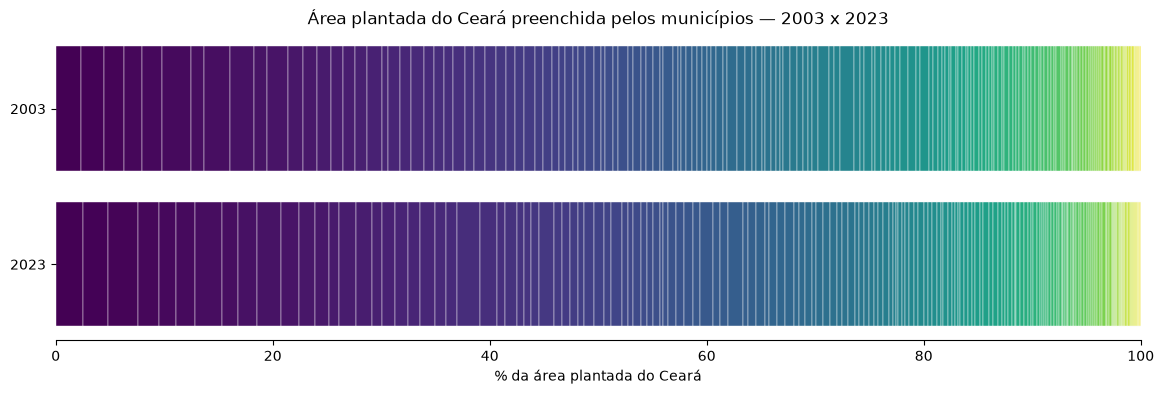

In [50]:
participacao_municipios_area_plantada = pivot_municipios_area_plantada.div(pivot_municipios_area_plantada.sum(axis=1), axis=0) * 100
ordem_municipios_area_plantada = total_municipios_area_plantada.index
n_municipios = len(ordem_municipios_area_plantada)
cor_por_municipio_area_plantada = {m: cmap_municipios(i / n_municipios) for i, m in enumerate(ordem_municipios_area_plantada)}

fig, ax = plt.subplots(figsize=(14, 4))
for ano in anos_resumo:
    esquerda = 0
    for municipio in ordem_municipios_area_plantada:
        pct = participacao_municipios_area_plantada.loc[ano, municipio]
        ax.barh(str(ano), pct, left=esquerda, color=cor_por_municipio_area_plantada[municipio], edgecolor="#fcfcfb", linewidth=0.3)
        if pct > 3:
            ax.text(esquerda + pct / 2, str(ano), municipio.replace(" - CE", ""), ha="center", va="center", fontsize=7, color="white", rotation=90)
        esquerda += pct

ax.invert_yaxis()
ax.set_xlabel("% da área plantada do Ceará")
ax.set_title("Área plantada do Ceará preenchida pelos municípios — 2003 x 2023")
ax.set_xlim(0, 100)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.show()

### Área colhida

In [51]:
pivot_municipios_area_colhida = df_nome[
    (df_nome['variavel_nome'] == 'Área colhida') & (~df_nome['territorio_nome'].isin(['Brasil', 'Ceará']))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')
pivot_municipios_area_colhida

territorio_nome,Abaiara - CE,Acarape - CE,Acaraú - CE,Acopiara - CE,Aiuaba - CE,Alcântaras - CE,Altaneira - CE,Alto Santo - CE,Amontada - CE,Antonina do Norte - CE,Apuiarés - CE,Aquiraz - CE,Aracati - CE,Aracoiaba - CE,Ararendá - CE,Araripe - CE,Aratuba - CE,Arneiroz - CE,Assaré - CE,Aurora - CE,Baixio - CE,Banabuiú - CE,Barbalha - CE,Barreira - CE,Barro - CE,Barroquinha - CE,Baturité - CE,Beberibe - CE,Bela Cruz - CE,Boa Viagem - CE,Brejo Santo - CE,Camocim - CE,Campos Sales - CE,Canindé - CE,Capistrano - CE,Caridade - CE,Caririaçu - CE,Cariré - CE,Cariús - CE,Carnaubal - CE,Cascavel - CE,Catarina - CE,Catunda - CE,Caucaia - CE,Cedro - CE,Chaval - CE,Chorozinho - CE,Choró - CE,Coreaú - CE,Crateús - CE,Crato - CE,Croatá - CE,Cruz - CE,Deputado Irapuan Pinheiro - CE,Ereré - CE,Eusébio - CE,Farias Brito - CE,Forquilha - CE,Fortaleza - CE,Fortim - CE,Frecheirinha - CE,General Sampaio - CE,Granja - CE,Granjeiro - CE,Graça - CE,Groaíras - CE,Guaiúba - CE,Guaraciaba do Norte - CE,Guaramiranga - CE,Hidrolândia - CE,Horizonte - CE,Ibaretama - CE,Ibiapina - CE,Ibicuitinga - CE,Icapuí - CE,Icó - CE,Iguatu - CE,Independência - CE,Ipaporanga - CE,Ipaumirim - CE,Ipu - CE,Ipueiras - CE,Iracema - CE,Irauçuba - CE,Itaitinga - CE,Itaiçaba - CE,Itapajé - CE,Itapipoca - CE,Itapiúna - CE,Itarema - CE,Itatira - CE,Jaguaretama - CE,Jaguaribara - CE,Jaguaribe - CE,Jaguaruana - CE,Jardim - CE,Jati - CE,Jijoca de Jericoacoara - CE,Juazeiro do Norte - CE,Jucás - CE,Lavras da Mangabeira - CE,Limoeiro do Norte - CE,Madalena - CE,Maracanaú - CE,Maranguape - CE,Marco - CE,Martinópole - CE,Massapê - CE,Mauriti - CE,Meruoca - CE,Milagres - CE,Milhã - CE,Miraíma - CE,Missão Velha - CE,Mombaça - CE,Monsenhor Tabosa - CE,Morada Nova - CE,Moraújo - CE,Morrinhos - CE,Mucambo - CE,Mulungu - CE,Nova Olinda - CE,Nova Russas - CE,Novo Oriente - CE,Ocara - CE,Orós - CE,Pacajus - CE,Pacatuba - CE,Pacoti - CE,Pacujá - CE,Palhano - CE,Palmácia - CE,Paracuru - CE,Paraipaba - CE,Parambu - CE,Paramoti - CE,Pedra Branca - CE,Penaforte - CE,Pentecoste - CE,Pereiro - CE,Pindoretama - CE,Piquet Carneiro - CE,Pires Ferreira - CE,Poranga - CE,Porteiras - CE,Potengi - CE,Potiretama - CE,Quiterianópolis - CE,Quixadá - CE,Quixelô - CE,Quixeramobim - CE,Quixeré - CE,Redenção - CE,Reriutaba - CE,Russas - CE,Saboeiro - CE,Salitre - CE,Santa Quitéria - CE,Santana do Acaraú - CE,Santana do Cariri - CE,Senador Pompeu - CE,Senador Sá - CE,Sobral - CE,Solonópole - CE,São Benedito - CE,São Gonçalo do Amarante - CE,São João do Jaguaribe - CE,São Luís do Curu - CE,Tabuleiro do Norte - CE,Tamboril - CE,Tarrafas - CE,Tauá - CE,Tejuçuoca - CE,Tianguá - CE,Trairi - CE,Tururu - CE,Ubajara - CE,Umari - CE,Umirim - CE,Uruburetama - CE,Uruoca - CE,Varjota - CE,Viçosa do Ceará - CE,Várzea Alegre - CE
ano_nome,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003,4244.0,2393.0,20748.0,19853.0,8250.0,5932.0,1194.0,8907.0,25641.0,2032.0,2395.0,4730.0,20251.0,10834.0,5366.0,9670.0,4935.0,3785.0,9361.0,18746.0,1940.0,3126.0,4578.0,10363.0,13823.0,5373.0,8810.0,38534.0,33551.0,38936.0,16993.0,7873.0,10917.0,30979.0,11758.0,5146.0,7006.0,11610.0,4833.0,2118.0,24304.0,6628.0,9062.0,7450.0,6442.0,3320.0,17304.0,5120.0,5163.0,47448.0,6819.0,10120.0,18110.0,6678.0,2107.0,712.0,4199.0,5061.0,214.0,5563.0,6066.0,1665.0,10059.0,1404.0,4959.0,3415.0,2895.0,9411.0,1222.0,11957.0,4769.0,8703.0,7898.0,6235.0,17829.0,18923.0,7973.0,15208.0,13973.0,3943.0,19170.0,11750.0,1398.0,7792.0,1083.0,1607.0,9670.0,43430.0,9204.0,20260.0,14305.0,15213.0,2683.0,8754.0,7997.0,8172.0,4366.0,7478.0,1659.0,6361.0,8687.0,6070.0,12701.0,936.0,6231.0,11494.0,3434.0,10270.0,35348.0,4504.0,24060.0,9575.0,3673.0,10725.0,16786.0,8220.0,19627.0,2200.0,14772.0,5696.0,4064.0,2360.0,7056.0,25645.0,22670.0,3514.0,15332.0,1591.0,2903.0,2869.0,6880.0,2523.0,9210.0,9738.0,44456.0,4432.0,22517.0,2449.0,6083.0,12922.0,23

In [52]:
total_municipios_area_colhida = pivot_municipios_area_colhida.sum(axis=0).sort_values(ascending=False)
top8_melhores_area_colhida = total_municipios_area_colhida.head(8)
top8_piores_area_colhida = total_municipios_area_colhida.tail(8).sort_values()

print("Top 8 melhores municípios - Área colhida (soma 2003-2024):")
print(top8_melhores_area_colhida)
print()
print("Top 8 piores municípios - Área colhida (soma 2003-2024):")
print(top8_piores_area_colhida)

Top 8 melhores municípios - Área colhida (soma 2003-2024):
territorio_nome
Itapipoca - CE         894939.0
Beberibe - CE          837807.0
Bela Cruz - CE         819994.0
Canindé - CE           621721.0
Tauá - CE              604675.0
Santa Quitéria - CE    599409.0
Crateús - CE           583459.0
Parambu - CE           578004.0
dtype: float64

Top 8 piores municípios - Área colhida (soma 2003-2024):
territorio_nome
Fortaleza - CE        1941.0
Eusébio - CE          8653.0
Maracanaú - CE       10411.0
Pacatuba - CE        18649.0
Itaitinga - CE       18955.0
Guaramiranga - CE    19222.0
Baixio - CE          25847.0
Granjeiro - CE       27215.0
dtype: float64


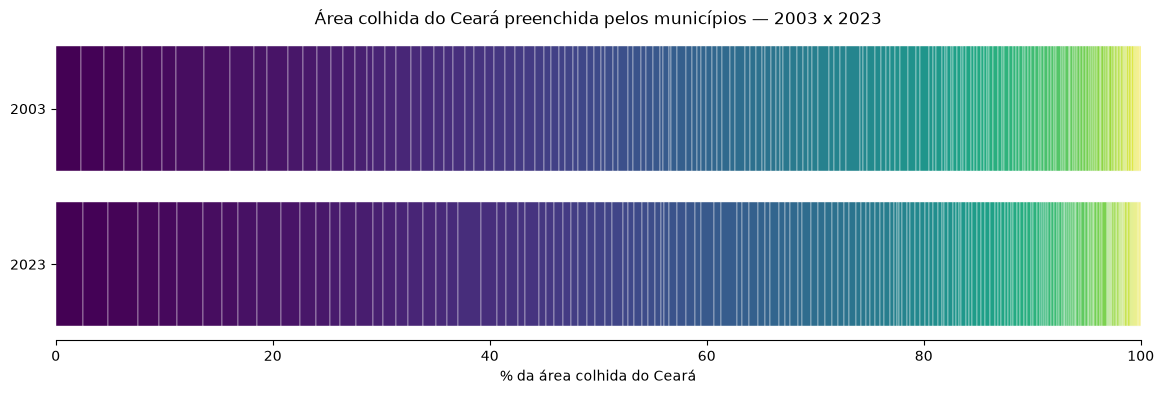

In [53]:
participacao_municipios_area_colhida = pivot_municipios_area_colhida.div(pivot_municipios_area_colhida.sum(axis=1), axis=0) * 100
ordem_municipios_area_colhida = total_municipios_area_colhida.index
n_municipios = len(ordem_municipios_area_colhida)
cor_por_municipio_area_colhida = {m: cmap_municipios(i / n_municipios) for i, m in enumerate(ordem_municipios_area_colhida)}

fig, ax = plt.subplots(figsize=(14, 4))
for ano in anos_resumo:
    esquerda = 0
    for municipio in ordem_municipios_area_colhida:
        pct = participacao_municipios_area_colhida.loc[ano, municipio]
        ax.barh(str(ano), pct, left=esquerda, color=cor_por_municipio_area_colhida[municipio], edgecolor="#fcfcfb", linewidth=0.3)
        if pct > 3:
            ax.text(esquerda + pct / 2, str(ano), municipio.replace(" - CE", ""), ha="center", va="center", fontsize=7, color="white", rotation=90)
        esquerda += pct

ax.invert_yaxis()
ax.set_xlabel("% da área colhida do Ceará")
ax.set_title("Área colhida do Ceará preenchida pelos municípios — 2003 x 2023")
ax.set_xlim(0, 100)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.show()

### Quantidade produzida

In [54]:
pivot_municipios_producao = df_nome[
    (df_nome['unidade'] == 'Toneladas') & (~df_nome['territorio_nome'].isin(['Brasil', 'Ceará']))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')
pivot_municipios_producao

territorio_nome,Abaiara - CE,Acarape - CE,Acaraú - CE,Acopiara - CE,Aiuaba - CE,Alcântaras - CE,Altaneira - CE,Alto Santo - CE,Amontada - CE,Antonina do Norte - CE,Apuiarés - CE,Aquiraz - CE,Aracati - CE,Aracoiaba - CE,Ararendá - CE,Araripe - CE,Aratuba - CE,Arneiroz - CE,Assaré - CE,Aurora - CE,Baixio - CE,Banabuiú - CE,Barbalha - CE,Barreira - CE,Barro - CE,Barroquinha - CE,Baturité - CE,Beberibe - CE,Bela Cruz - CE,Boa Viagem - CE,Brejo Santo - CE,Camocim - CE,Campos Sales - CE,Canindé - CE,Capistrano - CE,Caridade - CE,Caririaçu - CE,Cariré - CE,Cariús - CE,Carnaubal - CE,Cascavel - CE,Catarina - CE,Catunda - CE,Caucaia - CE,Cedro - CE,Chaval - CE,Chorozinho - CE,Choró - CE,Coreaú - CE,Crateús - CE,Crato - CE,Croatá - CE,Cruz - CE,Deputado Irapuan Pinheiro - CE,Ereré - CE,Eusébio - CE,Farias Brito - CE,Forquilha - CE,Fortaleza - CE,Fortim - CE,Frecheirinha - CE,General Sampaio - CE,Granja - CE,Granjeiro - CE,Graça - CE,Groaíras - CE,Guaiúba - CE,Guaraciaba do Norte - CE,Guaramiranga - CE,Hidrolândia - CE,Horizonte - CE,Ibaretama - CE,Ibiapina - CE,Ibicuitinga - CE,Icapuí - CE,Icó - CE,Iguatu - CE,Independência - CE,Ipaporanga - CE,Ipaumirim - CE,Ipu - CE,Ipueiras - CE,Iracema - CE,Irauçuba - CE,Itaitinga - CE,Itaiçaba - CE,Itapajé - CE,Itapipoca - CE,Itapiúna - CE,Itarema - CE,Itatira - CE,Jaguaretama - CE,Jaguaribara - CE,Jaguaribe - CE,Jaguaruana - CE,Jardim - CE,Jati - CE,Jijoca de Jericoacoara - CE,Juazeiro do Norte - CE,Jucás - CE,Lavras da Mangabeira - CE,Limoeiro do Norte - CE,Madalena - CE,Maracanaú - CE,Maranguape - CE,Marco - CE,Martinópole - CE,Massapê - CE,Mauriti - CE,Meruoca - CE,Milagres - CE,Milhã - CE,Miraíma - CE,Missão Velha - CE,Mombaça - CE,Monsenhor Tabosa - CE,Morada Nova - CE,Moraújo - CE,Morrinhos - CE,Mucambo - CE,Mulungu - CE,Nova Olinda - CE,Nova Russas - CE,Novo Oriente - CE,Ocara - CE,Orós - CE,Pacajus - CE,Pacatuba - CE,Pacoti - CE,Pacujá - CE,Palhano - CE,Palmácia - CE,Paracuru - CE,Paraipaba - CE,Parambu - CE,Paramoti - CE,Pedra Branca - CE,Penaforte - CE,Pentecoste - CE,Pereiro - CE,Pindoretama - CE,Piquet Carneiro - CE,Pires Ferreira - CE,Poranga - CE,Porteiras - CE,Potengi - CE,Potiretama - CE,Quiterianópolis - CE,Quixadá - CE,Quixelô - CE,Quixeramobim - CE,Quixeré - CE,Redenção - CE,Reriutaba - CE,Russas - CE,Saboeiro - CE,Salitre - CE,Santa Quitéria - CE,Santana do Acaraú - CE,Santana do Cariri - CE,Senador Pompeu - CE,Senador Sá - CE,Sobral - CE,Solonópole - CE,São Benedito - CE,São Gonçalo do Amarante - CE,São João do Jaguaribe - CE,São Luís do Curu - CE,Tabuleiro do Norte - CE,Tamboril - CE,Tarrafas - CE,Tauá - CE,Tejuçuoca - CE,Tianguá - CE,Trairi - CE,Tururu - CE,Ubajara - CE,Umari - CE,Umirim - CE,Uruburetama - CE,Uruoca - CE,Varjota - CE,Viçosa do Ceará - CE,Várzea Alegre - CE
ano_nome,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003,11701.0,30259.0,32537.0,13461.0,8138.0,5859.0,2130.0,6004.0,52678.0,1549.0,1224.0,75282.0,23920.0,8040.0,7327.0,44492.0,16029.0,1941.0,8230.0,18994.0,2575.0,3980.0,142253.0,17795.0,18974.0,12462.0,26867.0,38842.0,39426.0,26378.0,37705.0,14359.0,20944.0,25486.0,12463.0,3658.0,14092.0,8333.0,6196.0,12906.0,36512.0,2942.0,3866.0,30170.0,7969.0,6381.0,11605.0,6519.0,3589.0,51908.0,52478.0,12231.0,25479.0,4844.0,1989.0,4976.0,6463.0,2911.0,1101.0,15518.0,7093.0,573.0,10916.0,1901.0,12009.0,1955.0,9408.0,60562.0,4451.0,9605.0,13357.0,11670.0,217535.0,3589.0,5807.0,24672.0,23374.0,11662.0,13131.0,5637.0,27871.0,16015.0,1132.0,2845.0,1650.0,6134.0,39820.0,85950.0,6678.0,30108.0,16481.0,9740.0,1593.0,6302.0,7451.0,18922.0,4653.0,12864.0,5920.0,8748.0,18083.0,33524.0,17548.0,21784.0,27327.0,19073.0,1803.0,18598.0,44192.0,15263.0,30838.0,5795.0,1631.0,88307.0,17865.0,7936.0,11909.0,3238.0,17523.0,17592.0,11991.0,3956.0,5967.0,20648.0,10748.0,4787.0,48493.0,5273.0,12101.0,7192.0,4944.0,12152.0,168013.0,221374.0,31216.0,3297

In [55]:
total_municipios_producao = pivot_municipios_producao.sum(axis=0).sort_values(ascending=False)
top8_melhores_producao = total_municipios_producao.head(8)
top8_piores_producao = total_municipios_producao.tail(8).sort_values()

print("Top 8 melhores municípios - Quantidade produzida (soma 2003-2024):")
print(top8_melhores_producao)
print()
print("Top 8 piores municípios - Quantidade produzida (soma 2003-2024):")
print(top8_piores_producao)

Top 8 melhores municípios - Quantidade produzida (soma 2003-2024):
territorio_nome
São Benedito - CE           4764275.0
Paraipaba - CE              2943994.0
Ibiapina - CE               2577084.0
Guaraciaba do Norte - CE    2466177.0
Viçosa do Ceará - CE        2428705.0
Paracuru - CE               2091593.0
Tianguá - CE                1883540.0
Salitre - CE                1496537.0
dtype: float64

Top 8 piores municípios - Quantidade produzida (soma 2003-2024):
territorio_nome
Fortaleza - CE            11002.0
Iracema - CE              18606.0
General Sampaio - CE      19337.0
Antonina do Norte - CE    19627.0
Baixio - CE               20557.0
Miraíma - CE              21441.0
Groaíras - CE             24468.0
Jaguaribara - CE          24606.0
dtype: float64


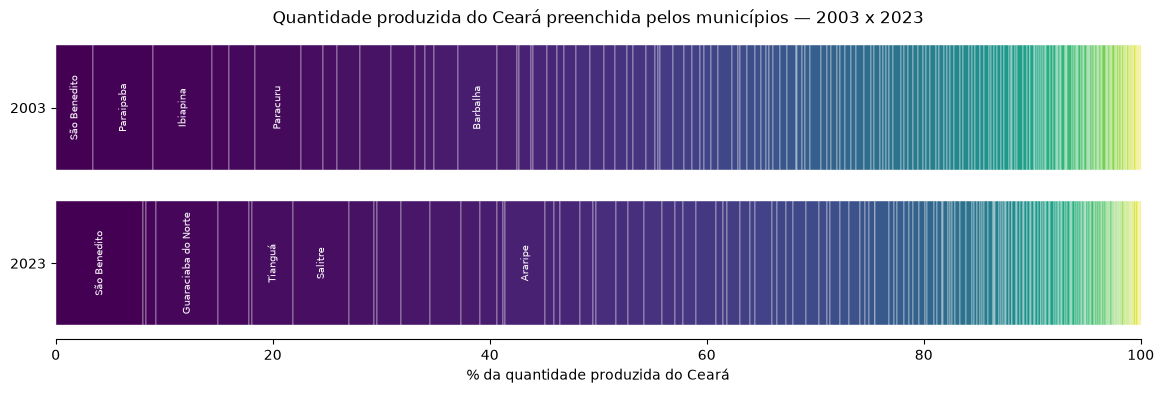

In [56]:
participacao_municipios_producao = pivot_municipios_producao.div(pivot_municipios_producao.sum(axis=1), axis=0) * 100
ordem_municipios_producao = total_municipios_producao.index
n_municipios = len(ordem_municipios_producao)
cor_por_municipio_producao = {m: cmap_municipios(i / n_municipios) for i, m in enumerate(ordem_municipios_producao)}

fig, ax = plt.subplots(figsize=(14, 4))
for ano in anos_resumo:
    esquerda = 0
    for municipio in ordem_municipios_producao:
        pct = participacao_municipios_producao.loc[ano, municipio]
        ax.barh(str(ano), pct, left=esquerda, color=cor_por_municipio_producao[municipio], edgecolor="#fcfcfb", linewidth=0.3)
        if pct > 3:
            ax.text(esquerda + pct / 2, str(ano), municipio.replace(" - CE", ""), ha="center", va="center", fontsize=7, color="white", rotation=90)
        esquerda += pct

ax.invert_yaxis()
ax.set_xlabel("% da quantidade produzida do Ceará")
ax.set_title("Quantidade produzida do Ceará preenchida pelos municípios — 2003 x 2023")
ax.set_xlim(0, 100)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.show()

## Crescimento (2003 → 2023)

### Produtos (Ceará)

In [57]:
crescimento_produtos_valor = (projecao_valor_ceara.loc[2023] / projecao_valor_ceara.loc[2003]).sort_values(ascending=False)

print("Crescimento do valor da produção por produto (Ceará, 2003 → 2023):")
for produto, fator in crescimento_produtos_valor.items():
    print(f"{produto}: {fator:.2f}x")

Crescimento do valor da produção por produto (Ceará, 2003 → 2023):
Banana (cacho): 6.00x
Mandioca: 4.36x
Castanha de caju: 2.07x
Feijão (em grão): 1.82x
Melão: 1.82x
Cana-de-açúcar: 1.78x
Milho (em grão): 1.54x


In [58]:
crescimento_produtos_area_plantada = (projecao_area_plantada_ceara.loc[2023] / projecao_area_plantada_ceara.loc[2003]).sort_values(ascending=False)

print("Crescimento da área plantada por produto (Ceará, 2003 → 2023):")
for produto, fator in crescimento_produtos_area_plantada.items():
    print(f"{produto}: {fator:.2f}x")

Crescimento da área plantada por produto (Ceará, 2003 → 2023):
Banana (cacho): 0.88x
Milho (em grão): 0.85x
Mandioca: 0.82x
Castanha de caju: 0.77x
Feijão (em grão): 0.59x
Melão: 0.52x
Cana-de-açúcar: 0.26x


In [59]:
crescimento_produtos_area_colhida = (projecao_area_colhida_ceara.loc[2023] / projecao_area_colhida_ceara.loc[2003]).sort_values(ascending=False)

print("Crescimento da área colhida por produto (Ceará, 2003 → 2023):")
for produto, fator in crescimento_produtos_area_colhida.items():
    print(f"{produto}: {fator:.2f}x")

Crescimento da área colhida por produto (Ceará, 2003 → 2023):
Banana (cacho): 0.85x
Milho (em grão): 0.85x
Mandioca: 0.82x
Castanha de caju: 0.77x
Feijão (em grão): 0.59x
Melão: 0.52x
Cana-de-açúcar: 0.26x


In [60]:
crescimento_produtos_producao = (projecao_producao_ceara.loc[2023] / projecao_producao_ceara.loc[2003]).sort_values(ascending=False)

print("Crescimento da quantidade produzida por produto (Ceará, 2003 → 2023):")
for produto, fator in crescimento_produtos_producao.items():
    print(f"{produto}: {fator:.2f}x")

Crescimento da quantidade produzida por produto (Ceará, 2003 → 2023):
Banana (cacho): 1.23x
Mandioca: 0.96x
Melão: 0.66x
Castanha de caju: 0.59x
Milho (em grão): 0.48x
Feijão (em grão): 0.33x
Cana-de-açúcar: 0.32x


### Municípios

In [61]:
crescimento_municipios_valor = (pivot_municipios_valor.loc[2023] / pivot_municipios_valor.loc[2003]).replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)

print("Top 10 municípios que mais cresceram - Valor da produção (2003 → 2023):")
for municipio, fator in crescimento_municipios_valor.head(10).items():
    print(f"{municipio}: {fator:.2f}x")

Top 10 municípios que mais cresceram - Valor da produção (2003 → 2023):
Varjota - CE: 19.45x
Apuiarés - CE: 16.23x
Umirim - CE: 10.61x
Palhano - CE: 9.65x
Uruburetama - CE: 9.62x
Itaitinga - CE: 8.73x
Russas - CE: 8.42x
Granja - CE: 8.25x
Paramoti - CE: 8.19x
Limoeiro do Norte - CE: 7.74x


In [62]:
crescimento_municipios_area_plantada = (pivot_municipios_area_plantada.loc[2023] / pivot_municipios_area_plantada.loc[2003]).replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)

print("Top 10 municípios que mais cresceram - Área plantada (2003 → 2023):")
for municipio, fator in crescimento_municipios_area_plantada.head(10).items():
    print(f"{municipio}: {fator:.2f}x")

Top 10 municípios que mais cresceram - Área plantada (2003 → 2023):
Paramoti - CE: 4.28x
Caridade - CE: 3.17x
Apuiarés - CE: 2.43x
Carnaubal - CE: 1.98x
Camocim - CE: 1.77x
Mombaça - CE: 1.68x
Martinópole - CE: 1.64x
Uruburetama - CE: 1.63x
Granja - CE: 1.59x
Umirim - CE: 1.48x


In [63]:
crescimento_municipios_area_colhida = (pivot_municipios_area_colhida.loc[2023] / pivot_municipios_area_colhida.loc[2003]).replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)

print("Top 10 municípios que mais cresceram - Área colhida (2003 → 2023):")
for municipio, fator in crescimento_municipios_area_colhida.head(10).items():
    print(f"{municipio}: {fator:.2f}x")

Top 10 municípios que mais cresceram - Área colhida (2003 → 2023):
Paramoti - CE: 4.28x
Caridade - CE: 3.17x
Apuiarés - CE: 2.43x
Carnaubal - CE: 1.98x
Camocim - CE: 1.77x
Mombaça - CE: 1.68x
Martinópole - CE: 1.64x
Granja - CE: 1.59x
Umirim - CE: 1.48x
Tururu - CE: 1.48x


In [64]:
crescimento_municipios_producao = (pivot_municipios_producao.loc[2023] / pivot_municipios_producao.loc[2003]).replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)

print("Top 10 municípios que mais cresceram - Quantidade produzida (2003 → 2023):")
for municipio, fator in crescimento_municipios_producao.head(10).items():
    print(f"{municipio}: {fator:.2f}x")

Top 10 municípios que mais cresceram - Quantidade produzida (2003 → 2023):
Palhano - CE: 5.68x
Varjota - CE: 5.50x
Granja - CE: 3.74x
Icapuí - CE: 3.31x
Martinópole - CE: 3.03x
Umirim - CE: 3.01x
Apuiarés - CE: 2.89x
Camocim - CE: 2.57x
Salitre - CE: 2.20x
Guaraciaba do Norte - CE: 2.13x


## Fortaleza, Maracanaú, São Gonçalo do Amarante e Caucaia

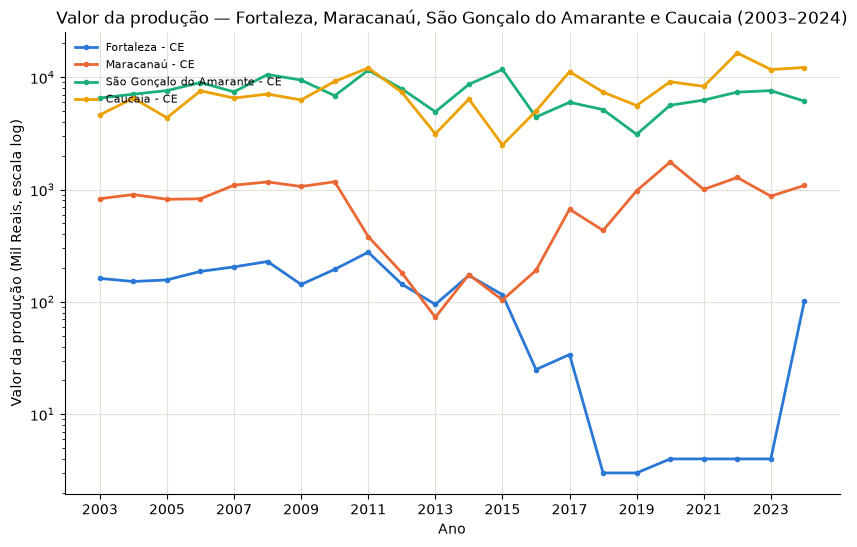

In [65]:
cidades_investigar = ["Fortaleza - CE", "Maracanaú - CE", "São Gonçalo do Amarante - CE", "Caucaia - CE"]
cores_investigar = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
cor_por_cidade_investigar = dict(zip(cidades_investigar, cores_investigar))

serie_cidades_valor = df_nome[
    (df_nome['unidade'] == 'Mil Reais') & (df_nome['territorio_nome'].isin(cidades_investigar))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_investigar:
    serie = serie_cidades_valor[municipio]
    ax.plot(serie.index, serie.values, color=cor_por_cidade_investigar[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("Valor da produção (Mil Reais, escala log)")
ax.set_title("Valor da produção — Fortaleza, Maracanaú, São Gonçalo do Amarante e Caucaia (2003–2024)")
ax.set_xticks(range(2003, 2025, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

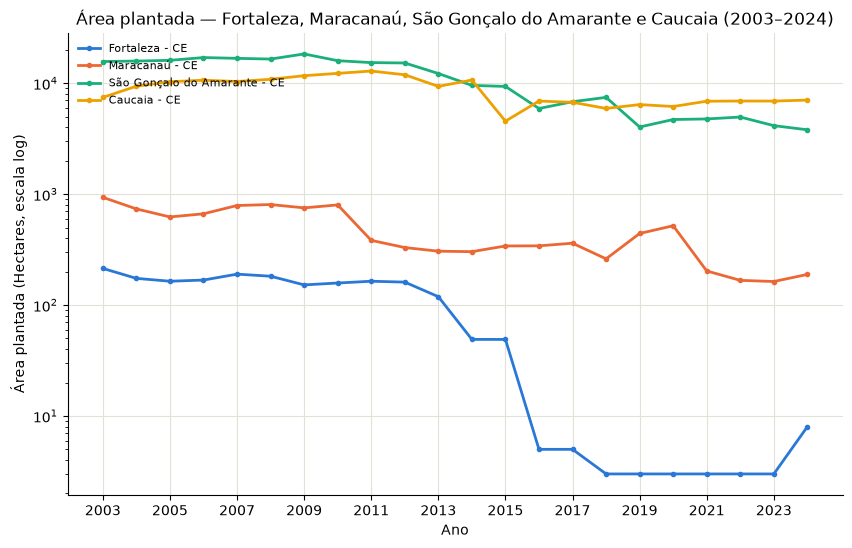

In [66]:
serie_cidades_area_plantada = df_nome[
    (df_nome['variavel_nome'] == 'Área plantada ou destinada à colheita') & (df_nome['territorio_nome'].isin(cidades_investigar))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_investigar:
    serie = serie_cidades_area_plantada[municipio]
    ax.plot(serie.index, serie.values, color=cor_por_cidade_investigar[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("Área plantada (Hectares, escala log)")
ax.set_title("Área plantada — Fortaleza, Maracanaú, São Gonçalo do Amarante e Caucaia (2003–2024)")
ax.set_xticks(range(2003, 2025, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

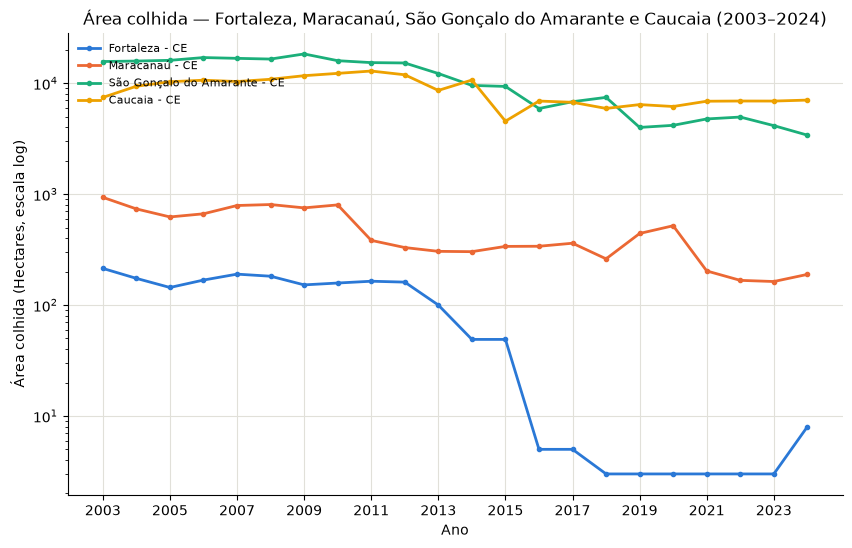

In [67]:
serie_cidades_area_colhida = df_nome[
    (df_nome['variavel_nome'] == 'Área colhida') & (df_nome['territorio_nome'].isin(cidades_investigar))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_investigar:
    serie = serie_cidades_area_colhida[municipio]
    ax.plot(serie.index, serie.values, color=cor_por_cidade_investigar[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("Área colhida (Hectares, escala log)")
ax.set_title("Área colhida — Fortaleza, Maracanaú, São Gonçalo do Amarante e Caucaia (2003–2024)")
ax.set_xticks(range(2003, 2025, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

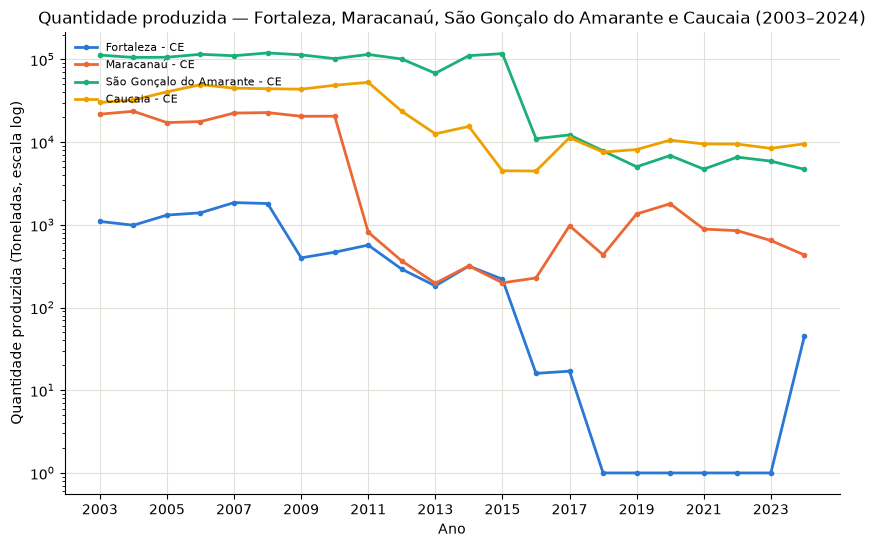

In [68]:
serie_cidades_producao = df_nome[
    (df_nome['unidade'] == 'Toneladas') & (df_nome['territorio_nome'].isin(cidades_investigar))
].pivot_table(index='ano_nome', columns='territorio_nome', values='valor', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 6))
for municipio in cidades_investigar:
    serie = serie_cidades_producao[municipio]
    ax.plot(serie.index, serie.values, color=cor_por_cidade_investigar[municipio], linewidth=2, marker="o", markersize=3, label=municipio)

ax.set_yscale("log")
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade produzida (Toneladas, escala log)")
ax.set_title("Quantidade produzida — Fortaleza, Maracanaú, São Gonçalo do Amarante e Caucaia (2003–2024)")
ax.set_xticks(range(2003, 2025, 2))
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper left")

plt.show()

## Perda de Safra (Área colhida / Área plantada) — Ceará

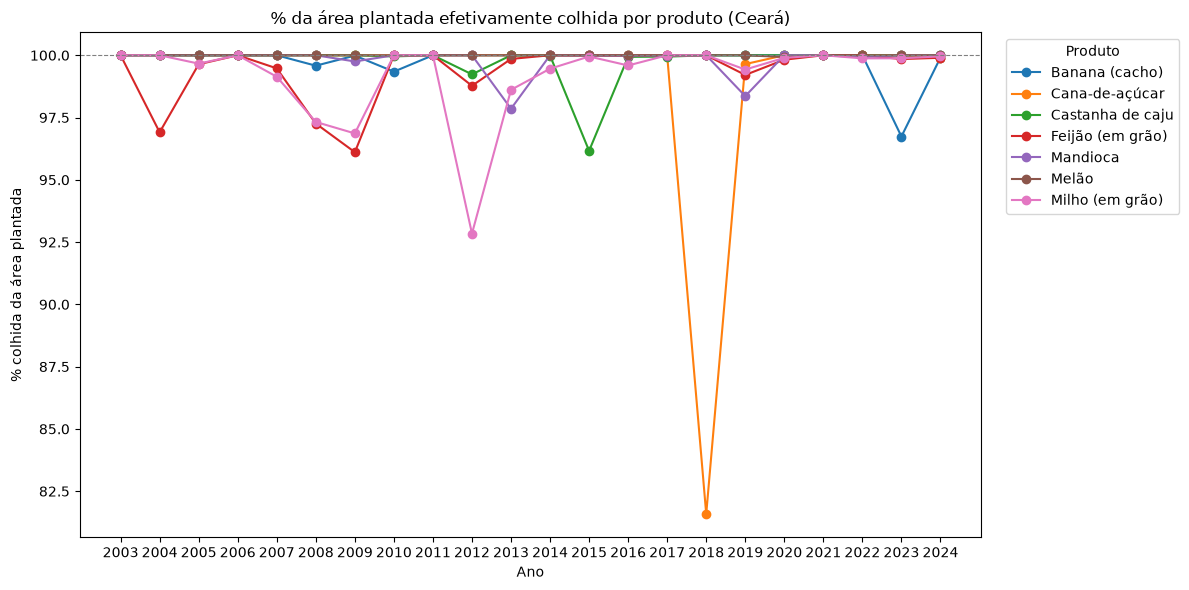

In [69]:
perda_safra_ceara = (projecao_area_colhida_ceara / projecao_area_plantada_ceara) * 100

fig, ax = plt.subplots(figsize=(12, 6))
perda_safra_ceara.plot(ax=ax, marker='o')
ax.set_title('% da área plantada efetivamente colhida por produto (Ceará)')
ax.set_xlabel('Ano')
ax.set_ylabel('% colhida da área plantada')
ax.set_xticks(perda_safra_ceara.index)
ax.axhline(100, color='gray', linewidth=0.8, linestyle='--')
ax.legend(title='Produto', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [70]:
print(perda_safra_ceara)

produto_nome  Banana (cacho)  Cana-de-açúcar  Castanha de caju  Feijão (em grão)    Mandioca       Melão  Milho (em grão)
ano_nome                                                                                                                 
2003              100.000000      100.000000        100.000000        100.000000  100.000000  100.000000       100.000000
2004              100.000000      100.000000        100.000000         96.908640  100.000000  100.000000       100.000000
2005              100.000000      100.000000        100.000000         99.639368  100.000000  100.000000        99.664705
2006              100.000000      100.000000        100.000000        100.000000  100.000000  100.000000       100.000000
2007              100.000000      100.000000         99.997607         99.474359  100.000000  100.000000        99.138110
2008               99.581178      100.000000        100.000000         97.258890  100.000000  100.000000        97.323839
2009               99.98

## Boxplot do Valor da Produção por Produto (Ceará)

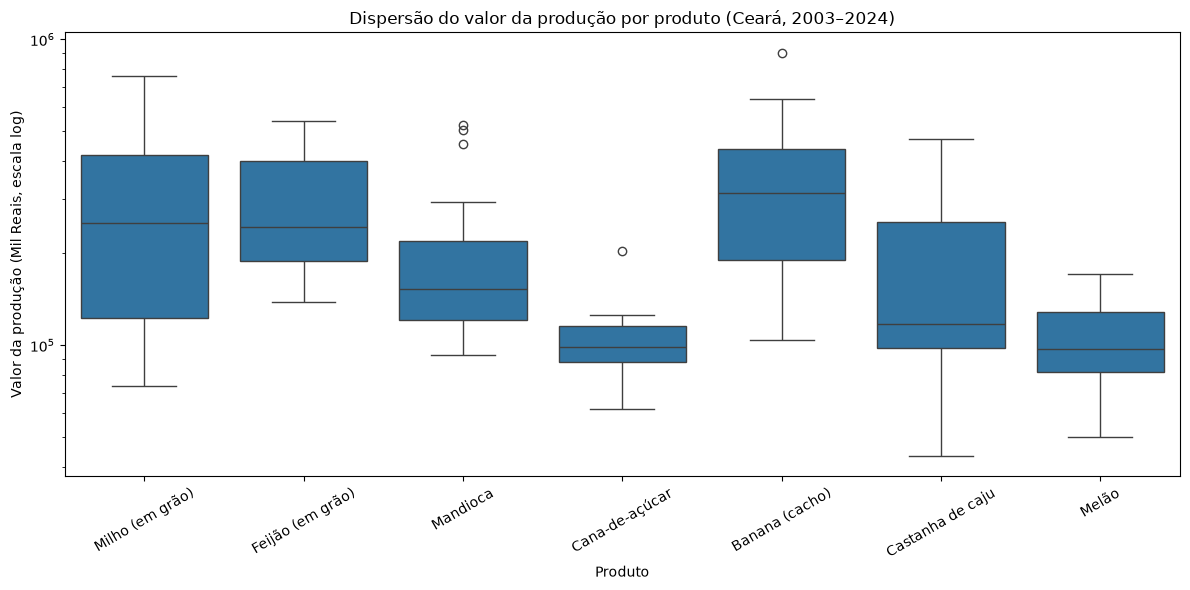

In [71]:
valor_ceara_por_produto = df_nome[(df_nome['unidade'] == 'Mil Reais') & (df_nome['territorio_nome'] == 'Ceará')]

fig, ax = plt.subplots(figsize=(12, 6))
sb.boxplot(data=valor_ceara_por_produto, x='produto_nome', y='valor', ax=ax)
ax.set_yscale('log')
ax.set_xlabel('Produto')
ax.set_ylabel('Valor da produção (Mil Reais, escala log)')
ax.set_title('Dispersão do valor da produção por produto (Ceará, 2003–2024)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Correlação entre Métricas (Ceará)

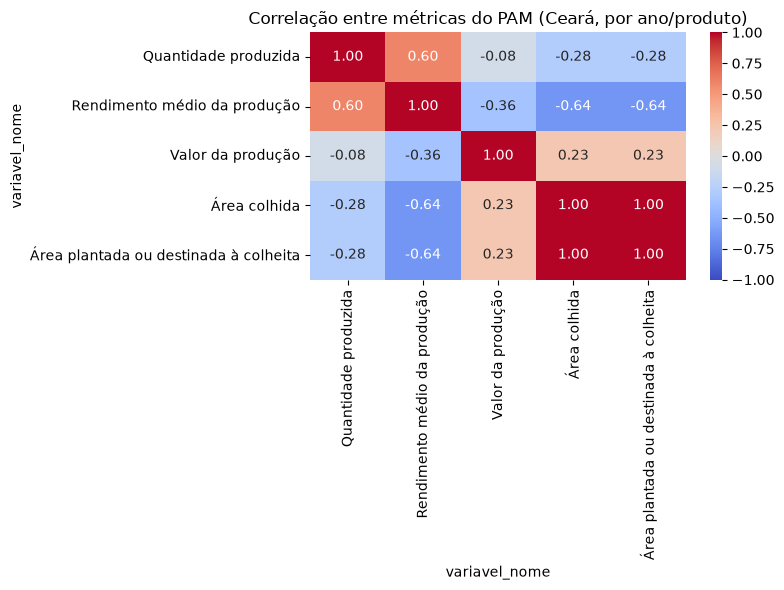

In [72]:
metricas_ceara = df_nome[df_nome['territorio_nome'] == 'Ceará'].pivot_table(
    index=['ano_nome', 'produto_nome'], columns='variavel_nome', values='valor'
)

correlacao_metricas = metricas_ceara.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sb.heatmap(correlacao_metricas, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlação entre métricas do PAM (Ceará, por ano/produto)')
plt.tight_layout()
plt.show()

**Leitura da correlação:**

- **Área colhida × Área plantada (1.00):** correlação praticamente perfeita — quase tudo que é plantado acaba sendo colhido, coerente com a baixa perda de safra vista antes.
- **Quantidade produzida × Rendimento médio (0.60):** positiva moderada — anos/produtos com rendimento (kg/ha) maior tendem a produzir mais em volume.
- **Rendimento médio × Área plantada/colhida (-0.64):** negativa forte — produtos que ocupam mais área (Milho, Feijão) tendem a ter rendimento por hectare menor que produtos de área menor, puxando a correlação pra baixo.
- **Valor da produção × demais métricas (0.23 com área, -0.08 com quantidade, -0.36 com rendimento):** todas fracas — o valor em Mil Reais é muito mais influenciado pelo preço de mercado do produto do que pelo volume/área plantada em si.

Importante: essa matriz mistura produtos diferentes (cada linha é ano × produto), então reflete o perfil de cada cultura (ex: Cana-de-açúcar tem área e rendimento grandes, Melão tem área pequena), não uma relação causal dentro de uma única safra.